# Helmholtz 1D implementation


## Import necessary modules

In [227]:
# make use of QLS jupyter env
import numpy as np
import scipy as sc
from linear_solvers import NumPyLinearSolver, HHL
import time
from linear_solvers.matrices.tridiagonal_toeplitz import TridiagonalToeplitz
from linear_solvers.matrices.numpy_matrix import NumPyMatrix
from numerical_solvers.thomas_algorithm import numerical_solvers
from qiskit.quantum_info import Statevector
from qiskit.utils import QuantumInstance
from qiskit import Aer, execute, transpile
from qiskit_aer import StatevectorSimulator, QasmSimulator, AerSimulator
from scipy.sparse import diags
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# remove print limits
np.set_printoptions(threshold=np.inf)
warnings.simplefilter('ignore')

## Define utility functions

In [216]:


def normalize(arr, t_min, t_max):
    """
    Normalize an array to a specified range [t_min, t_max].
    
    For data that spans both negative and positive values, this function
    uses a symmetric normalization (dividing by the ub absolute value)
    to preserve the zero-crossing and the relative oscillatory behavior.
    
    For data that does not span both signs, it uses standard min-max normalization.
    """
    arr = np.array(arr)
    # Check if data spans both negative and positive values
    # Use symmetric normalization:
    max_abs = np.max(np.abs(arr))
    # Avoid division by zero
    if max_abs < 1e-12:
        norm_arr = arr.copy()
    else:
        norm_arr = arr / max_abs
    # If the target range is symmetric about zero (e.g., [-1, 1]),
    # then simply scale by the ub absolute value.
    # Otherwise, map [-1, 1] to [t_min, t_max]:
    if t_min == -1 and t_max == 1:
        return norm_arr
    else:
        # Mapping from [-1,1] to [t_min, t_max]:
        return ((norm_arr + 1) / 2) * (t_max - t_min) + t_min
        
def get_solution_vector_qasm(solution, N, vector):
    """
    Extracts and normalizes the solution vector from measurement results of a quantum circuit.
    Assumes that solution.circuit_results contains a counts dictionary from a QASM simulation,
    where the measured bits include the solution register as the last log2(len(vector)) bits.
    
    Args:
        solution: The LinearSolverResult object containing circuit_results (counts) and euclidean_norm.
        N: The total number of qubits in the quantum circuit.
        vector: The input vector (length must be a power of two).
    
    Returns:
        A normalized solution vector, scaled by the computed Euclidean norm.
    
    Raises:
        ValueError: If the length of the input vector is not a power of two.
    """
     # Record the start time
    start_time = time.time()
    
    vector_length = len(vector)
  
    sol_length = int(np.log2(vector_length))  # Number of qubits in solution register
    start = N - sol_length  # Starting index of the solution register
    
    counts = solution._qasm_results  # Access the counts dictionary
    total_shots = sum(counts.values())  # Total number of measurements
    
    hist = counts
    # Create a histogram from the counts
    bitstrings = list(hist.keys())
    frequencies = list(hist.values())
   
    # plt.figure(figsize=(10, 6))
    # plt.xticks(rotation=45, ha='right')
    # plt.bar(bitstrings, frequencies)
    # plt.xlabel('Bitstrings')
    # plt.ylabel('Counts')
    # plt.grid(axis='y', alpha=0.5)
    # plt.title('Histogram of QASM Results')
    # plt.show()
    sol_counts = np.zeros(vector_length)  # Initialize to match solution indices
    
    #new historgram where bitstring[0] == 1
    success_bitstrings = {bitstring: count for bitstring, count in counts.items() if bitstring[0] == '1'} 
    # plt.figure(figsize=(10, 6))
    # plt.xticks(rotation=45, ha='right')
    # plt.bar(success_bitstrings.keys(), success_bitstrings.values())
    # plt.xlabel('Bitstrings')
    # plt.ylabel('Counts')
    # plt.grid(axis='y', alpha=0.5)
    # plt.title('Histogram of QASM Results with First Bit Set to 1')
    
    for bitstring, count in counts.items():
        # only extract if from 0 to start entires are 0
        clock_bits = bitstring[1:start]
        if bitstring[0] == '1' and all(bit == '0' for bit in clock_bits):
            #print('success bitstring:', bitstring)
            #print('start bitstring:', bitstring)
            sol_bitstring = bitstring[start:]  # Extract the solution register bits
            #print('state bitstring:', sol_bitstring)
            index = int(sol_bitstring, 2)
            #if sol_counts[index] != 0:
                #print('     Repeated bitstring, index:', index)
                
            #print('computed index:', index)
            
            sol_counts[index] +=  count
            
            #print('sol_counts:', sol_counts)
    
  
    sol_probs = sol_counts / total_shots
    sol_amplitudes = np.sqrt(abs(sol_probs))
    
    norm = solution.euclidean_norm  # Precomputed norm from the quantum algorithm
    sol_norm = np.linalg.norm(sol_amplitudes)
    
    if sol_norm == 0:
        normalized_amplitudes = sol_amplitudes
    else:
        normalized_amplitudes = norm * sol_amplitudes / sol_norm
        
    end_time = time.time()
    print(f"qasm time: {end_time - start_time}")
    return normalized_amplitudes


def get_solution_vector_statevector(solution, N, vector):
    """Extracts and normalizes simulated state vector from LinearSolverResult."""
    # Record the start time
    start_time_total = time.time()
    
    # Calculate the start and end indices
    start_time = time.time()
    start = 2**(N-1)
    print(f"Time after calculating start index: {time.time() - start_time}")
    
    start_time = time.time()
    fin = 2**(N-1) + len(vector)
    print(f"Time after calculating end index: {time.time() - start_time}")
    
    start_time = time.time()
    # Extract the solution vector from the statevector
    print(type(solution.state))
    solution_vector = Statevector(solution.state).data[start:fin].real
    print(f"Time after extracting solution vector: {time.time() - start_time}")
    
    start_time = time.time()
    # Retrieve the precomputed norm
    norm = solution.euclidean_norm
    print(f"Time after retrieving norm: {time.time() - start_time}")
    
    start_time = time.time()
    # Normalize the solution vector
    normalized_solution_vector = norm * solution_vector / np.linalg.norm(solution_vector)
    print(f"Time after normalizing solution vector: {time.time() - start_time}")
    
    # Record the end time
    end_time = time.time()
    print(f"State Vector total function time: {end_time - start_time_total}")
    
    return normalized_solution_vector

def statevector(solution, N, vector, Nshots):
    """Extracts and normalizes simulated state vector from LinearSolverResult."""
    # Record the start time
    start_time_total = time.time()
    start = int(2**(N-1))
    fin = int(2**(N-1) + len(vector))
    
    qc = solution.state.copy()
    qc.remove_final_measurements()

    backend = Aer.get_backend('statevector_simulator')
    job = execute(qc, backend, shots=Nshots)
    result = job.result()
    
    # Extract the state vector
    sv = result.get_statevector(qc)
    
    # Extraction
    solution_vector = sv.data[start:fin]
    solution_vector = np.real(solution_vector)
    
    #print("Statevector from Aer execution:", solution_vector)
    # Record the end time
    end_time = time.time()
    #print(f"State Vector execution time: {end_time - start_time_total}")
    
    return solution_vector

def qasm(solution, N, vector, backend, Nshots, backend_options, visual=False):
    """
    Extracts and normalizes the solution vector from measurement results of a quantum circuit.
    The circuit is executed using the provided backend and backend_options.
    
    Assumes that the measured bitstrings include the solution register as the last log2(len(vector)) bits.
    """

    # Record the start time
    start_time = time.time()
    
    vector_length = len(vector)
    sol_length = int(np.log2(vector_length))  # Number of qubits in solution register
    start = N - sol_length  # Starting index of the solution register
    
    # Get a copy of the circuit and add measurements
    qc = solution.state.copy()
    qc.measure_all()
    
    # Execute the circuit using the provided backend and backend options
    backend.set_options(**backend_options)
    job = execute(qc, backend, shots=Nshots)
    result = job.result()
    counts = result.get_counts(qc)
    total_shots = sum(counts.values())
    
    if visual:
        hist = counts
        # Create a histogram from the counts
        bitstrings = list(hist.keys())
        frequencies = list(hist.values())
    
        plt.figure(figsize=(8, 5))
        plt.xticks(rotation=45, ha='right')
        plt.bar(bitstrings, frequencies, color='blue')
        plt.xlabel('Measures Bitstrings')
        plt.ylabel('Counts')
        plt.grid(axis='y', alpha=0.5)
        #plt.title('Histogram of QASM Results')
        plt.show()

    sol_counts = np.zeros(vector_length)  # Initialize the solution counts array

    # Process counts: extract only those bitstrings where the first bit is '1' and the clock bits (from index 1 to start-1) are all '0'
    for bitstring, count in counts.items():
        clock_bits = bitstring[1:start]
        if bitstring[0] == '1' and all(b == '0' for b in clock_bits):
            # Extract the solution register bits (from position 'start' onward)
            sol_bitstring = bitstring[start:]
            index = int(sol_bitstring, 2)
            sol_counts[index] += count

    # Compute probabilities, then amplitudes (square roots of probabilities)
    sol_probs = sol_counts / total_shots
    sol_amplitudes = np.sqrt(np.abs(sol_probs))
    
    # Scale the amplitudes by the euclidean norm provided by the solution object
    sol_norm = np.linalg.norm(sol_amplitudes)
    if sol_norm == 0:
        normalized_amplitudes = sol_amplitudes
    else:
        normalized_amplitudes = sol_amplitudes / sol_norm
        
    end_time = time.time()
    print(f"qasm execution time: {end_time - start_time}")
    
    return normalized_amplitudes

def construct_TT_matrix(main_diag, off_diag, size):
    '''
    Construct a tridiagonal Toeplitz matrix using the main diagonal and off-diagonal elements.
    '''
    matrix = diags([off_diag, main_diag, off_diag], offsets=[-1, 0, 1], shape=(size, size)).toarray()
    
    #print(f'Matrix Condition number: {np.linalg.cond(matrix)}')
    return matrix

def construct_preconditioner(matrix, vector,h,k, alpha):
    """
    Return the numpy preconditioned matrix and vector for the given matrix and vector.
    """
    main_diag = matrix[0, 0]
    off_diag = matrix[0, 1]
    size = matrix.shape[0]

    # Build the complex-shifted Laplacian preconditioner
    a_shifted = -4 / h**2 + k**2 * (1 - 1j * alpha)
    b_shifted = 1 / h**2
    a_real = np.real(a_shifted)
    a_imag = np.imag(a_shifted)
    b_real = np.real(b_shifted)
    P_real = diags([b_real, a_real, b_real], [-1, 0, 1], shape=(size, size)).toarray()
    P_imag = diags([0, a_imag, 0], [-1, 0, 1], shape=(size, size)).toarray()
    P_complex = P_real + 1j * P_imag
    # Ensure the preconditioner matrix is positive definite
   # 7) Classical preconditioning
    P_inv = np.linalg.inv(P_complex)
    prec_matrix_complex = P_inv @ matrix
    prec_vector_complex = P_inv @ vector
    prec_matrix = np.real(prec_matrix_complex)
    prec_vector = np.real(prec_vector_complex)

    # 8) Approximate preconditioned matrix as TridiagonalToeplitz
    a_prec = np.mean(np.diag(prec_matrix))
    b_prec = np.mean(np.diag(prec_matrix, 1))

    matrix_prec = construct_TT_matrix(a_prec, b_prec, size)
    print('Preconditioner Condition number: ', np.linalg.cond(matrix_prec))
    return matrix_prec, prec_vector

def solve_1DHHL(matrix, vector, qubits, epsilon=0.01):
    '''
    Solves the 1D HHL
    '''
    a = matrix[0, 0]
    b = matrix[0, 1]
    # Set up quantum instance
    backend = Aer.get_backend('qasm_simulator')
    backend_options = {
    'max_parallel_threads': 8,      # use up to 4 threads
    'max_parallel_experiments': 16,    # run up to 2 experiments in parallel
    'seed_simulator': 42,            # set a seed for reproducibility
    }
    num_shots = 10000
    quantum_instance = QuantumInstance(backend, shots=num_shots, backend_options=backend_options)

    tridi_mat = TridiagonalToeplitz(qubits, a, b)
    print(tridi_mat.depth())
    hhl_solver = HHL(epsilon=epsilon, quantum_instance=quantum_instance)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, vector)
 
    return hhl_solution_obj

def solve_1DHHL_Numpy(matrix, vector, qubits, epsilon=0.001):
    '''
    Solves the 1D HHL
    '''
    a = matrix[0, 0]
    b = matrix[0, 1]
    # Set up quantum instance
    backend = Aer.get_backend('qasm_simulator')
    backend_options = {
    'max_parallel_threads': 8,      # use up to 4 threads
    'max_parallel_experiments': 16,    # run up to 2 experiments in parallel
    'seed_simulator': 42,            # set a seed for reproducibility
    }
    num_shots = 1000
    quantum_instance = QuantumInstance(backend, shots=num_shots, backend_options=backend_options)

    mat = NumPyMatrix(matrix)
    hhl_solver = HHL(epsilon=epsilon, quantum_instance=quantum_instance)
    hhl_solution_obj = hhl_solver.solve(mat, vector)
 
    return hhl_solution_obj

def solve_1DHHL_prec(matrix, vector, qubits, alpha ,h,k,epsilon=0.001):
    '''
    Solves the 1D HHL using preconditioning
    '''
    matrix_prec, vector_prec = construct_preconditioner(matrix, vector, alpha, h, k)
    a = matrix_prec[0, 0]
    b = matrix_prec[0, 1]

    # Set up quantum instance
    backend = Aer.get_backend('qasm_simulator')
    backend_options = {
    'max_parallel_threads': 8,      # use up to 4 threads
    'max_parallel_experiments': 16,    # run up to 2 experiments in parallel
    'seed_simulator': 42,            # set a seed for reproducibility
    }
    num_shots = 1000
    quantum_instance = QuantumInstance(backend, shots=num_shots, backend_options=backend_options)

    tridi_mat = TridiagonalToeplitz(qubits, a, b)
    hhl_solver = HHL(epsilon=epsilon, quantum_instance=quantum_instance)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, vector_prec)
 
    return hhl_solution_obj

def solve_1DThomas(matrix, vector):
    '''
    Solves the 1D Thomas algorithm
    '''
    
    # Compare to thomas
    matrix1 = matrix.copy()
    vector1 = vector.copy()
    thomas = numerical_solvers()
    num_solution = thomas.solve_tridiagonal_thomas(matrix1, vector1)
    #num_solution = np.concatenate(([0], num_solution, [0]))
    #num_solution = normalize(num_solution, -1.0, 1.0)
    return num_solution

def L2_error(u, v):
    """Calculate the L2 error between two vectors."""
    return np.linalg.norm(u - v) / np.linalg.norm(u)

def Linf_error(u, v):
    """Calculate the L-infinity error between two vectors."""
    return np.max(np.abs(u - v))


## Validation of solution

0
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
Circuit depth: 28831


<Figure size 1200x500 with 0 Axes>

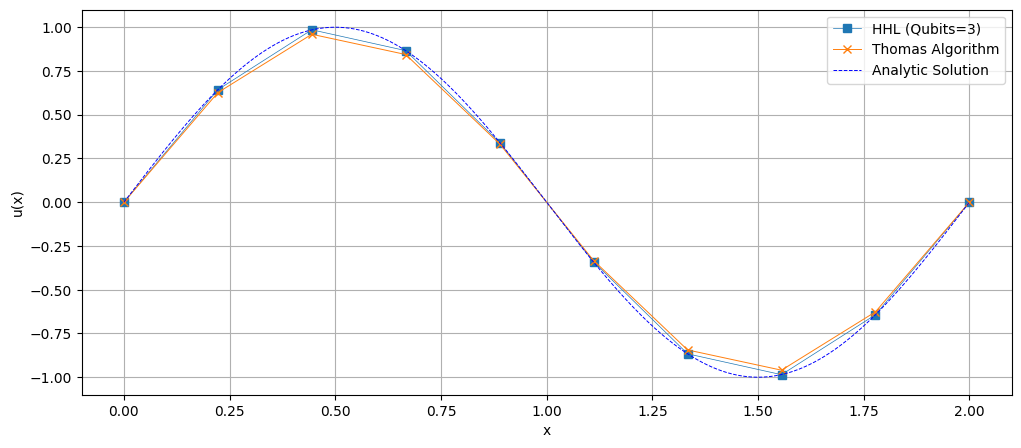

In [ ]:
# Build the matrix A
NUM_QUBITS = 5
MATRIX_SIZE = 2 ** NUM_QUBITS
# Define the number of qubits to test
qubit_numbers = [ 3]#,4,5]

# Initialize lists to store results
errors_hhl = []

# from qiskit.utils import algorithm_globals ### Only use for big simulations hi
# algorithm_globals.massive = True
errors_thomas = []

# Plot the results for each qubit number on a single graph
plt.figure(figsize=(12, 5))

# Loop over different qubit numbers
for NUM_QUBITS in qubit_numbers:
    MATRIX_SIZE = 2 ** NUM_QUBITS
    L = 2.0                                     # Domain length
    N = MATRIX_SIZE                             # No. of points
    h = L / (N+1)                               # Step size
    k = 5.0                                     # Wavenumber (avoid k = nπ for stability!)
    eps = 0.01                                  # Error tolerance
    numShots = 1000                             # Number of shots for QASM simulation
    x_numerical = np.linspace(0, L, N+2)[1:-1]  # Interior points

    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off diagonal

    matrix = construct_TT_matrix(a, b, N)  # Construct the tridiagonal Toeplitz matrix
    vector = (k**2 - np.pi**2) * np.sin(np.pi * x_numerical)
    

    x_fine = np.linspace(0, L, 1000)  # Fine grid for smooth curve
    u_analytic = np.sin(np.pi * x_fine)
    u_error = np.sin(np.pi * x_numerical)

    hhl_solution_obj = solve_1DHHL(matrix, vector, NUM_QUBITS, eps)
    hhl_norm = hhl_solution_obj.euclidean_norm
    
  
    solution_hhl = statevector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, vector, numShots)
    psi_norm = np.linalg.norm(solution_hhl)
    x_phys =  (hhl_norm / psi_norm) * solution_hhl
    x_phys = x_phys * np.linalg.norm(vector)
    
    tridi_vector = np.concatenate(([0], x_phys, [0]))
    #tridi_vector = normalize(tridi_vector, -1, 1)
    #print(tridi_vector)
    mae_hhl = np.mean(np.abs(tridi_vector[1:len(tridi_vector)-1] - u_error))
    errors_hhl.append(mae_hhl)

    # Compare to thomas
    num_solution =solve_1DThomas(matrix, vector)
    num_solution = np.concatenate(([0], num_solution, [0]))
    
    #num_solution = normalize(num_solution, -1, 1)
    #print(num_solution)
    mae_thomas = np.mean(np.abs(num_solution[1:len(num_solution)-1] - u_error))
    errors_thomas.append(mae_thomas)

    # Plot the results for each qubit number
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 1, 1)
    plt.plot(np.concatenate(([0], x_numerical, [L])), tridi_vector, 's-', linewidth=0.5, label=f'HHL (Qubits={NUM_QUBITS})')
    plt.plot(np.concatenate(([0], x_numerical, [L])), num_solution, 'x-', linewidth=0.7, label=f'Thomas Algorithm')

# Plot the analytic solution
plt.subplot(1, 1, 1)
plt.plot(x_fine, u_analytic, 'b--', linewidth=0.7, label='Analytic Solution')
plt.xlabel('x')
plt.grid(True)
plt.ylabel('u(x)')
plt.legend()
plt.show()

In [ ]:
# plot erros
plt.figure(figsize=(12, 5))
plt.subplot(1, 1, 1)
plt.plot(qubit_numbers, errors_hhl, 's-', linewidth=0.5, label='HHL Error')
plt.plot(qubit_numbers, errors_thomas, 'x-', linewidth=0.7, label='Thomas Algorithm Error')
plt.xlabel('Number of Qubits')
plt.ylabel('L2 Error')

NUM_QUBITS = [1, 2, 3]
# compute the grid size now h
h = [L / (pow(2, n) + 1) for n in NUM_QUBITS]
# print the gradient of the log curve for error convergence
from scipy.stats import linregress
res = linregress(np.log(h), np.log(errors_hhl))
print(f"Gradient of the log log curve for error convergence HHL (log h vs log E): {res.slope:.4f}")
res = linregress(np.log(h), np.log(errors_thomas))
print(f"Gradient of the log curve for error convergence Thomas (log h vs log E): {res.slope:.4f}")


## Smooth mesh convergence

### Run Simulation

Matrix Condition number: 6.85410196624969
Eigenvalues: [ 15.45084972  -9.54915028 -65.45084972 -40.45084972]
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
  L2 norm error (Thomas): 0.204443
  Mean absolute error (Thomas): 0.224199
  L2 norm error (HHL Statevector): 0.214079
  Mean absolute error (HHL Statevector): 0.238982


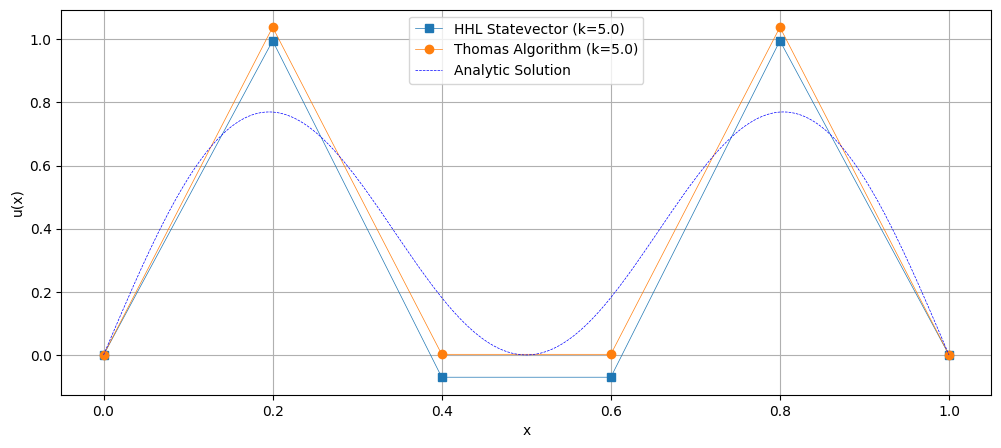

Matrix Condition number: 22.419555357285205
Eigenvalues: [-289.23020457 -261.09919979 -218.         -165.13100478 -108.86899522
   15.23020457  -12.90080021  -56.        ]
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  3
  L2 norm error (Thomas): 0.049466
  Mean absolute error (Thomas): 0.046097
  L2 norm error (HHL Statevector): 0.055800
  Mean absolute error (HHL Statevector): 0.053973


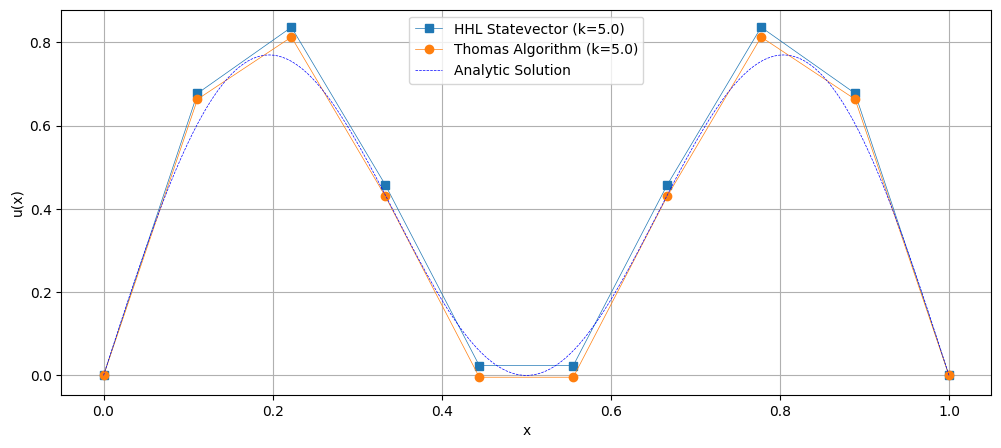

Matrix Condition number: 79.90551950191724
Eigenvalues: [-1121.15845162 -1091.9689486  -1044.42550445  -980.14715415
  -901.32281983  -810.63676964  -711.17720826  -606.33111177
  -499.66888823  -394.82279174    15.15845162   -14.0310514
   -61.57449555  -125.85284585  -204.67718017  -295.36323036]
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  8 Number of b qubits :  4
  L2 norm error (Thomas): 0.012947
  Mean absolute error (Thomas): 0.012370
  L2 norm error (HHL Statevector): 0.020146
  Mean absolute error (HHL Statevector): 0.018789


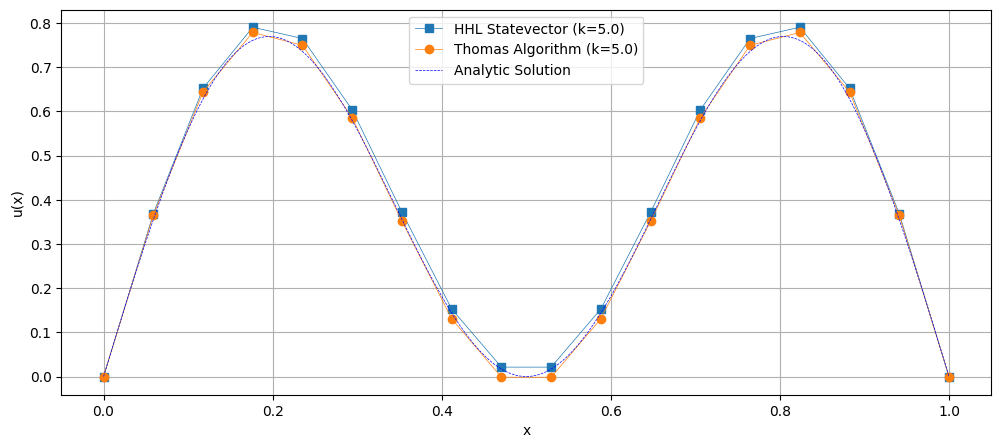

Matrix Condition number: 300.92961643459074
Eigenvalues: [   15.13784736   -14.35929736   -63.22430347  -131.01464189
  -217.11639283  -320.74980549  -440.97635965  -576.70726501
  -726.71332147  -889.63605095 -1064.         -1248.22610168
 -1440.64597589 -1639.51703846 -1843.03828224 -2049.36658734
 -2256.63341266 -2462.96171776 -2666.48296154 -2865.35402411
 -3057.77389832 -4321.13784736 -4291.64070264 -4242.77569653
 -4174.98535811 -4088.88360717 -3985.25019451 -3865.02364035
 -3729.29273499 -3579.28667853 -3416.36394905 -3242.        ]
 Number of ancilla qubits :  4  Number of flag qubits :  1  Number of clock qubits :  10 Number of b qubits :  5
  L2 norm error (Thomas): 0.003372
  Mean absolute error (Thomas): 0.003118
  L2 norm error (HHL Statevector): 0.010308
  Mean absolute error (HHL Statevector): 0.009882


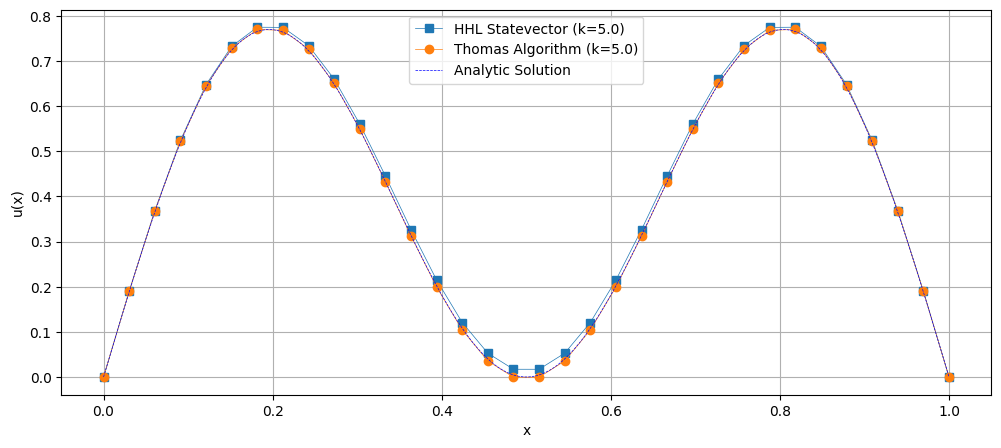

In [190]:
NUM_QUBITS = [2, 3, 4, 5]


# Plot the results for each qubit number on a single graph
# Loop over different qubit numbe
eps = 0.00001                           # Error tolerance
numShots = 10000                             # Number of shots for QASM simulation
x_fine = np.linspace(0, L, 200)


# Loop over different wave numbers
k = 5.0  # Define a range of wave numbers to investigate#[3.8, 3.9, 4]  # Define a range of wave numbers to investigate
results = {}

for n in NUM_QUBITS:
    MATRIX_SIZE = 2 ** n
    L = 1.0                                     # Domain length
    N = MATRIX_SIZE                             # No. of points
    h = L / (N+1)                               # Step size
    x_numerical = np.linspace(0, L, N+2)[1:-1]  # Interior points
    #u_error = np.sin(2 * np.pi * x_numerical)
    u_error = np.sin(2 * np.pi * x_numerical) * np.cos(np.pi * x_numerical)
    u_fine = np.sin(2 * np.pi * x_fine) * np.cos(np.pi * x_fine)

    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off diagonal

    matrix = construct_TT_matrix(a, b, N)  # Construct the tridiagonal Toeplitz matrix
    print(f"Matrix Condition number: {np.linalg.cond(matrix)}")
    #vector = ( k**2 - 4 * (np.pi)**2) * np.sin(2 * np.pi * x_numerical)
    vector =  k**2 * np.sin(2 * np.pi* x_numerical) * np.cos(np.pi* x_numerical) - 4 * (np.pi)**2 * np.sin(np.pi * x_numerical) * np.cos(2 * np.pi *x_numerical) - 5 * (np.pi)**2 * np.sin(2 * np.pi* x_numerical) * np.cos(np.pi* x_numerical) 
    
    #print the eigenvalues of the matrix
    eigenvalues = np.linalg.eigvals(matrix)
    
    print(f"Eigenvalues: {eigenvalues}")
    
    # reciprocal eigenvalue spectrum
    spectrum = max(1/eigenvalues) - min(1/eigenvalues)
    if spectrum < eps:
        print('Warning: Spectrum is too small')
    
    hhl_solution_obj = solve_1DHHL(matrix, vector, n, eps)
    hhl_norm = hhl_solution_obj.euclidean_norm
    solution_hhl = statevector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, vector, numShots)
    #solution_hhl = qasm(hhl_solution_obj, hhl_solution_obj.state.num_qubits, vector, Aer.get_backend('qasm_simulator'), numShots, backend_options={'max_parallel_threads': 8, 'max_parallel_experiments': 16})
    psi_norm = np.linalg.norm(solution_hhl)
    x_phys = (hhl_norm / psi_norm) * solution_hhl
    x_phys = x_phys * np.linalg.norm(vector)
    
    
    # Compare to thomas
    num_solution = solve_1DThomas(matrix, vector)
    num_solution = np.concatenate(([0], num_solution, [0]))
    
    #x_phys = solution_hhl * np.linalg.norm(num_solution)/ np.linalg.norm(solution_hhl)
    hhl_vector_sv = np.concatenate(([0], x_phys, [0]))
    
    # Get the L2 and Linf errors
    num_diff = num_solution[1:len(num_solution)-1] - u_error
    E2_thomas = np.sqrt(h * np.sum(num_diff**2))
    Einf_thomas = np.max(np.abs(num_diff))
    mae_thomas = np.mean(np.abs(num_diff))

    
    hhl_diff = hhl_vector_sv[1:len(hhl_vector_sv)-1] - u_error
    E2_hhl = np.sqrt(h * np.sum(hhl_diff**2))
    Einf_hhl = np.max(np.abs(hhl_diff))
    mae_hhl = np.mean(np.abs(hhl_diff))

    print(f"  L2 norm error (Thomas): {E2_thomas:.6f}")
    # print(f"  L∞ norm error (Thomas): {Einf_thomas:.6f}")
    print(f"  Mean absolute error (Thomas): {mae_thomas:.6f}")
    # print()
    print(f"  L2 norm error (HHL Statevector): {E2_hhl:.6f}")
    # print(f"  L∞ norm error (HHL Statevector): {Einf_hhl:.6f}")
    print(f"  Mean absolute error (HHL Statevector): {mae_hhl:.6f}")
    
    # Store results for each wave number
    results[n] = {
        'L2 error (Thomas)': E2_thomas,
        'L∞ error (Thomas)': Einf_thomas,
        'Mean absolute error (Thomas)': mae_thomas,
        'L2 error (HHL Statevector)': E2_hhl,
        'L∞ error (HHL Statevector)': Einf_hhl,
        'Mean absolute error (HHL Statevector)': mae_hhl,
        "condition": np.linalg.cond(matrix),
        "spectrum": spectrum
    }

    # Plot the results
    plt.figure(figsize=(12, 5))
    plt.plot(np.concatenate(([0], x_numerical, [L])), hhl_vector_sv, 's-', linewidth=0.5, label=f'HHL Statevector (k={k})')
    plt.plot(np.concatenate(([0], x_numerical, [L])), num_solution, 'o-', linewidth=0.5, label=f'Thomas Algorithm (k={k})')
    plt.plot(x_fine, u_fine, 'b--', linewidth=0.5, label='Analytic Solution')
    plt.xlabel('x')
    plt.ylabel('u(x)')
    #plt.title(f'Wave Number Investigation (k={k})')
    plt.savefig(f'figures/mesh_convergence/gauss_qubit={n}_k={k}_eps={eps}.png', dpi=300)
    plt.legend()
    plt.grid(True)
    plt.show()


### Plot Results

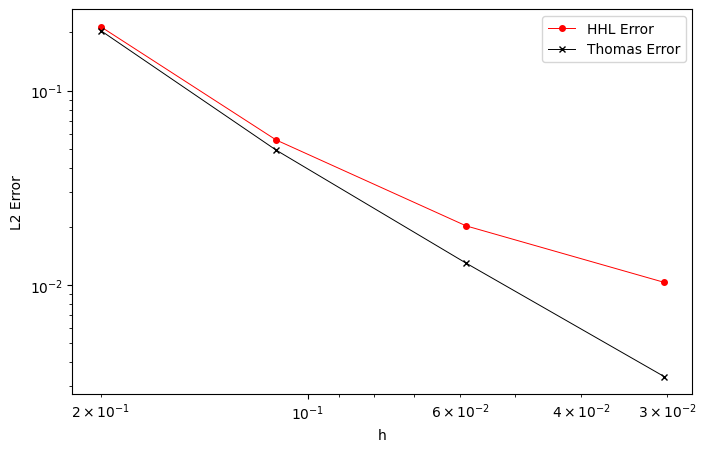

Gradient of the log curve for error convergence HHL  (n vs log E): -1.0119
Gradient of the log curve for error convergence Thomas (n vs log e): -1.3655
Gradient of the log log curve for error convergence HHL (log h vs log E): 1.5993
Gradient of the log curve for error convergence Thomas (log h vs log E): 2.1661


In [191]:
# Plot the error convergence
plt.figure(figsize=(8, 5))
plt.plot(NUM_QUBITS, [results[k]['L2 error (HHL Statevector)'] for k in NUM_QUBITS], 'ro-', label='HHL Error', linewidth=0.7, markersize=4)
plt.plot(NUM_QUBITS, [results[k]['L2 error (Thomas)'] for k in NUM_QUBITS], 'kx-', label='Thomas Error', linewidth=0.7, markersize=4)
plt.xlabel('Number of Qubits')
plt.ylabel('L2 Error')
plt.legend()
#plt.savefig('figures/1D_Mesh_convergence.png', dpi=300)
plt.close()

# add a log plot for the error convergence

# compute the grid size now h
h = [L / (pow(2, n) + 1) for n in NUM_QUBITS]
plt.figure(figsize=(8, 5))
plt.plot(h, [results[k]['L2 error (HHL Statevector)'] for k in NUM_QUBITS], 'ro-', label='HHL Error', linewidth=0.7, markersize=4)
plt.plot(h, [results[k]['L2 error (Thomas)'] for k in NUM_QUBITS], 'kx-', label='Thomas Error', linewidth=0.7, markersize=4)
plt.xlabel('h')
plt.ylabel('L2 Error')
plt.yscale('log')
#reverse the x axis
plt.gca().invert_xaxis()
plt.xscale('log')
plt.legend()
#plt.savefig('figures/1D_Mesh_convergence_log.png', dpi=300)
plt.savefig(f'figures/mesh_convergence/gauss_loglog_h_vs_L2.png', dpi=300)
plt.show()

# print the gradient of the log curve for error convergence
from scipy.stats import linregress
res = linregress(NUM_QUBITS, np.log([results[k]['L2 error (HHL Statevector)'] for k in NUM_QUBITS]))
print(f"Gradient of the log curve for error convergence HHL  (n vs log E): {res.slope:.4f}")
res = linregress(NUM_QUBITS, np.log([results[k]['L2 error (Thomas)'] for k in NUM_QUBITS]))
print(f"Gradient of the log curve for error convergence Thomas (n vs log e): {res.slope:.4f}")

# print the gradient of the log curve for error convergence
from scipy.stats import linregress
res = linregress(np.log(h), np.log([results[k]['L2 error (HHL Statevector)'] for k in NUM_QUBITS]))
print(f"Gradient of the log log curve for error convergence HHL (log h vs log E): {res.slope:.4f}")
res = linregress(np.log(h), np.log([results[k]['L2 error (Thomas)'] for k in NUM_QUBITS]))
print(f"Gradient of the log curve for error convergence Thomas (log h vs log E): {res.slope:.4f}")


# Non-Smooth Mesh convergence

## run simulation

Matrix Condition number: 8.000000000000005
[6.63294402e-72 1.60000000e+01]
 Number of ancilla qubits :  0  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  1
  L2 norm error (Thomas): 3.674235
  Mean absolute error (Thomas): 4.500000
  L2 norm error (HHL Statevector): 3.702055
  Mean absolute error (HHL Statevector): 4.534070


<Figure size 1200x500 with 0 Axes>

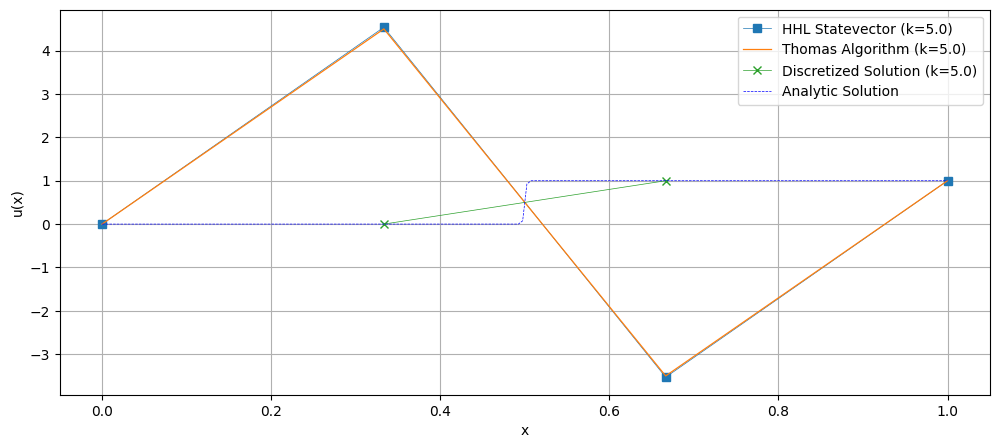

Matrix Condition number: 6.85410196624969
[ 12.5    6.25  18.75 -12.5 ]
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
  L2 norm error (Thomas): 0.229734
  Mean absolute error (Thomas): 0.250000
  L2 norm error (HHL Statevector): 0.226754
  Mean absolute error (HHL Statevector): 0.245539


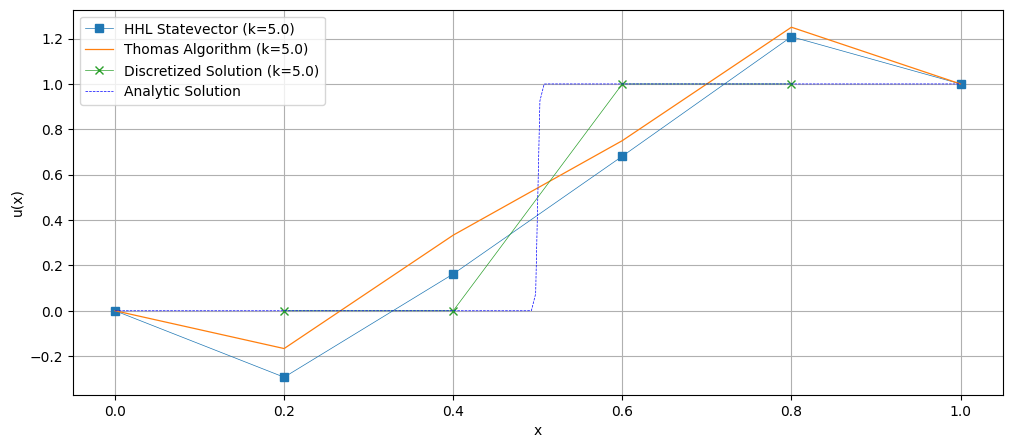

Matrix Condition number: 22.419555357285205
[ 1.67896396e-71  1.50991956e-23  2.02500000e+01  2.02500000e+01
  4.75000000e+00  4.75000000e+00  2.50000000e+01 -5.60000000e+01]
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  3
  L2 norm error (Thomas): 0.151352
  Mean absolute error (Thomas): 0.118834
  L2 norm error (HHL Statevector): 0.156832
  Mean absolute error (HHL Statevector): 0.123527


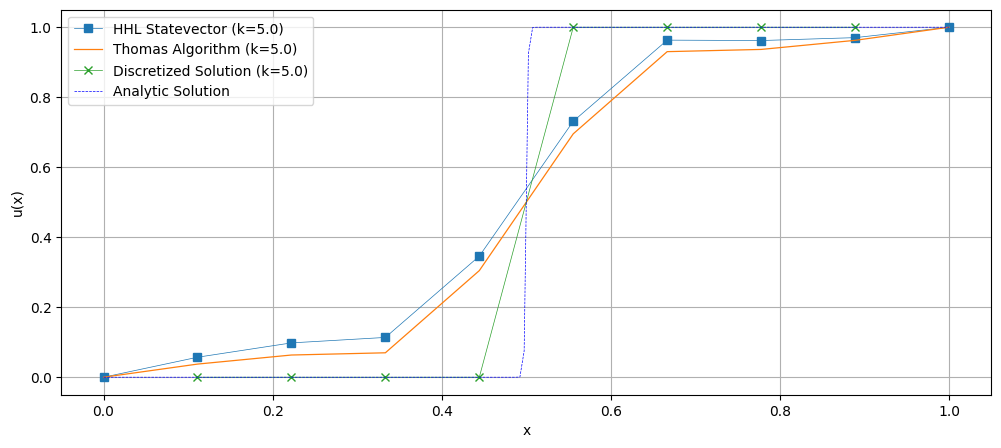

Matrix Condition number: 79.90551950191724
[ 4.49603397e-139  7.91651098e-114  2.78784130e-088  9.81753091e-063
  3.45729555e-037  1.21750495e-011  7.22500000e+001  7.22500000e+001
 -4.72500000e+001 -4.72500000e+001  2.50000000e+001  2.50000000e+001
  2.50000000e+001  2.50000000e+001  2.50000000e+001 -2.64000000e+002]
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  8 Number of b qubits :  4
  L2 norm error (Thomas): 0.091225
  Mean absolute error (Thomas): 0.045363
  L2 norm error (HHL Statevector): 0.097420
  Mean absolute error (HHL Statevector): 0.067949


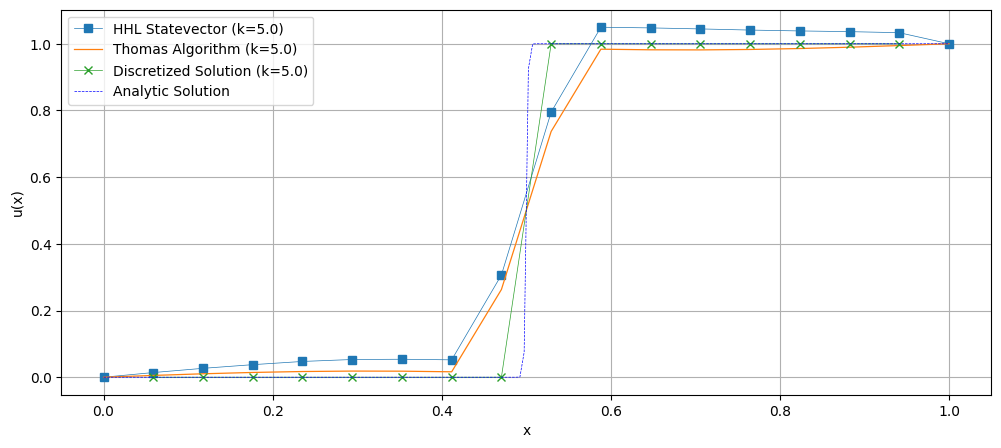

Matrix Condition number: 300.92961643459074
[ 1.17509633e-175  8.50124082e-163  1.23004547e-149  1.77975413e-136
  2.57512821e-123  3.72595582e-110  5.39108956e-097  7.80037339e-084
  1.12863688e-070  1.63302594e-057  2.36282702e-044  3.41877701e-031
  4.94663220e-018  7.15728567e-005  2.72249928e+002  2.72249863e+002
 -2.47249863e+002 -2.47249928e+002  2.49999284e+001  2.50000000e+001
  2.50000000e+001  2.50000000e+001  2.50000000e+001  2.50000000e+001
  2.50000000e+001  2.50000000e+001  2.50000000e+001  2.50000000e+001
  2.50000000e+001  2.50000000e+001  2.50000000e+001 -1.06400000e+003]
 Number of ancilla qubits :  4  Number of flag qubits :  1  Number of clock qubits :  10 Number of b qubits :  5
  L2 norm error (Thomas): 0.062431
  Mean absolute error (Thomas): 0.019206
  L2 norm error (HHL Statevector): 0.092582
  Mean absolute error (HHL Statevector): 0.068547


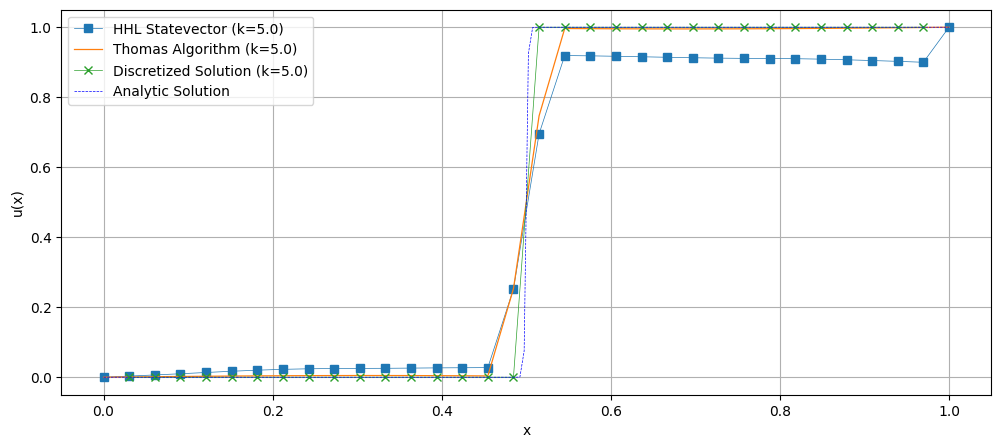

In [ ]:
NUM_QUBITS = [1, 2, 3 , 4, 5]


# Plot the results for each qubit number on a single graph
# Loop over different qubit numbe
eps = 0.00001                           # Error tolerance
numShots = 10000                             # Number of shots for QASM simulation
x_fine = np.linspace(0, L, 200)

# Loop over different wave numbers
k = 5.0  # Define a range of wave numbers to investigate#[3.8, 3.9, 4]  # Define a range of wave numbers to investigate
results = {}

for n in NUM_QUBITS:
    MATRIX_SIZE = 2 ** n
    L = 1.0                                     # Domain length
    N = MATRIX_SIZE                             # No. of points
    h = L / (N+1)                               # Step size
    x_numerical = np.linspace(0, L, N+2)[1:-1]  # Interior points
    c = 500.0                      
    tmp = x_numerical - L/2

    u_error = (1)/(1 + np.exp(-2 * c * tmp))
    u_fine =  (1)/(1 + np.exp(-2 * c *(x_fine - L/2)))
    
    
    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off diagonal

    matrix = construct_TT_matrix(a, b, N)  # Construct the tridiagonal Toeplitz matrix
    print(f"Matrix Condition number: {np.linalg.cond(matrix)}")
    #vector = (8 * c**2 * np.exp(-4 * c * tmp))/((1 + np.exp(-2 * c * tmp))**3) - (4 * c**2 * np.exp(-2 * c * tmp))/(1 + np.exp(-2 * c * tmp))**2 + k**2 * (1)/(1 + np.exp(-2 * c * tmp))
    vector = np.gradient(np.gradient(u_error, h), h) + k**2*u_error
    vector[0] -= b * u_error[0]
    vector[-1] -=b * u_error[-1]
    
    #np.where(x_numerical < L/2, 0.0, L)
    print(vector)
    
    #print the eigenvalues of the matrix
    eigenvalues = np.linalg.eigvals(matrix)
    
    #print(f"Eigenvalues: {eigenvalues}")
    
    # reciprocal eigenvalue spectrum
    spectrum = max(1/eigenvalues) - min(1/eigenvalues)
    if spectrum < eps:
        print('Warning: Spectrum is too small')
    
    hhl_solution_obj = solve_1DHHL(matrix, vector, n, eps)
    hhl_norm = hhl_solution_obj.euclidean_norm
    solution_hhl = statevector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, vector, numShots)
    #solution_hhl = qasm(hhl_solution_obj, hhl_solution_obj.state.num_qubits, vector, Aer.get_backend('qasm_simulator'), numShots, backend_options={'max_parallel_threads': 8, 'max_parallel_experiments': 16})
    psi_norm = np.linalg.norm(solution_hhl)
    x_phys = (hhl_norm / psi_norm) * solution_hhl
    x_phys = x_phys * np.linalg.norm(vector)
    
    
    # Compare to thomas
    num_solution = solve_1DThomas(matrix, vector)
    num_solution = np.concatenate(([0], num_solution, [1]))
    
    #x_phys = solution_hhl * np.linalg.norm(num_solution)/ np.linalg.norm(solution_hhl)
    hhl_vector_sv = np.concatenate(([0], x_phys, [1]))
    
    # Get the L2 and Linf errors
    num_diff = num_solution[1:len(num_solution)-1] - u_error
    E2_thomas = np.sqrt(h * np.sum(num_diff**2))
    Einf_thomas = np.max(np.abs(num_diff))
    mae_thomas = np.mean(np.abs(num_diff))

    
    hhl_diff = hhl_vector_sv[1:len(hhl_vector_sv)-1] - u_error
    E2_hhl = np.sqrt(h * np.sum(hhl_diff**2))
    Einf_hhl = np.max(np.abs(hhl_diff))
    mae_hhl = np.mean(np.abs(hhl_diff))

    print(f"  L2 norm error (Thomas): {E2_thomas:.6f}")
    # print(f"  L∞ norm error (Thomas): {Einf_thomas:.6f}")
    print(f"  Mean absolute error (Thomas): {mae_thomas:.6f}")
    # print()
    print(f"  L2 norm error (HHL Statevector): {E2_hhl:.6f}")
    # # print(f"  L∞ norm error (HHL Statevector): {Einf_hhl:.6f}")
    print(f"  Mean absolute error (HHL Statevector): {mae_hhl:.6f}")
    
    # Store results for each wave number
    results[n] = {
        'L2 error (Thomas)': E2_thomas,
        'L∞ error (Thomas)': Einf_thomas,
        'Mean absolute error (Thomas)': mae_thomas,
        'L2 error (HHL Statevector)': E2_hhl,
        'L∞ error (HHL Statevector)': Einf_hhl,
        'Mean absolute error (HHL Statevector)': mae_hhl,
        "condition": np.linalg.cond(matrix),
        "spectrum": spectrum
    }

    # Plot the results
    plt.figure(figsize=(12, 5))
    plt.plot(np.concatenate(([0], x_numerical, [L])), hhl_vector_sv, 's-', linewidth=0.5, label=f'HHL Statevector (k={k})')
    plt.plot(np.concatenate(([0], x_numerical, [L])), num_solution, '-', linewidth=0.9, label=f'Thomas Algorithm (k={k})')
    plt.plot(x_numerical , u_error, 'x-', linewidth=0.5, label=f'Discretized Solution (k={k})')
    plt.plot(x_fine, u_fine, 'b--', linewidth=0.5, label='Analytic Solution')
    plt.xlabel('x')
    plt.ylabel('u(x)')
    #plt.title(f'Wave Number Investigation (k={k})')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'figures/mesh_convergence/sigmoid_qubit={n}_k={k}_eps={eps}_.png', dpi=300)
    plt.show()


## get results

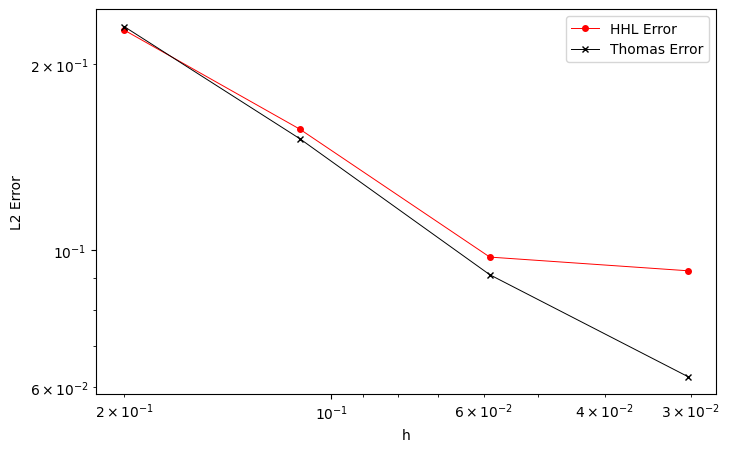

Gradient of the log curve for error convergence Thomas (n vs log e): -0.4415
Gradient of the log log curve for error convergence HHL (log h vs log E): 0.4993
Gradient of the log curve for error convergence Thomas (log h vs log E): 0.7003


In [189]:
# # Plot the error convergence
# plt.figure(figsize=(8, 5))
# plt.plot(NUM_QUBITS, [results[k]['L2 error (HHL Statevector)'] for k in NUM_QUBITS], 'ro-', label='HHL Error', linewidth=0.7, markersize=4)
# plt.plot(NUM_QUBITS, [results[k]['L2 error (Thomas)'] for k in NUM_QUBITS], 'kx-', label='Thomas Error', linewidth=0.7, markersize=4)
# plt.xlabel('Number of Qubits')
# plt.ylabel('L2 Error')
# plt.legend()
# #plt.savefig('figures/1D_Mesh_convergence.png', dpi=300)
# plt.close()

# add a log plot for the error convergence

# compute the grid size now h
NUM_QUBITS = [2, 3 , 4, 5]
h = [L / (pow(2, n) + 1) for n in NUM_QUBITS]
plt.figure(figsize=(8, 5))
plt.plot(h, [results[k]['L2 error (HHL Statevector)'] for k in NUM_QUBITS], 'ro-', label='HHL Error', linewidth=0.7, markersize=4)
plt.plot(h, [results[k]['L2 error (Thomas)'] for k in NUM_QUBITS], 'kx-', label='Thomas Error', linewidth=0.7, markersize=4)
plt.xlabel('h')
plt.ylabel('L2 Error')
plt.yscale('log')
# reverse the x axis
plt.gca().invert_xaxis()
plt.xscale('log')
plt.legend()
plt.savefig(f'figures/mesh_convergence/sigmoid_loglog_h_vs_L2_.png', dpi=300)
plt.show()

# print the gradient of the log curve for error convergence
from scipy.stats import linregress
# res = linregress(NUM_QUBITS, np.log([results[k]['L2 error (HHL Statevector)'] for k in NUM_QUBITS]))
# print(f"Gradient of the log curve for error convergence HHL  (n vs log E): {res.slope:.4f}")
res = linregress(NUM_QUBITS, np.log([results[k]['L2 error (Thomas)'] for k in NUM_QUBITS]))
print(f"Gradient of the log curve for error convergence Thomas (n vs log e): {res.slope:.4f}")

# print the gradient of the log curve for error convergence
from scipy.stats import linregress
res = linregress(np.log(h), np.log([results[k]['L2 error (HHL Statevector)'] for k in NUM_QUBITS]))
print(f"Gradient of the log log curve for error convergence HHL (log h vs log E): {res.slope:.4f}")
res = linregress(np.log(h), np.log([results[k]['L2 error (Thomas)'] for k in NUM_QUBITS]))
print(f"Gradient of the log curve for error convergence Thomas (log h vs log E): {res.slope:.4f}")


# QASM vs Statevector

### Run simulation

In [ ]:
# Build the matrix A
NUM_QUBITS = 4
MATRIX_SIZE = 2 ** NUM_QUBITS


# Plot the results for each qubit number on a single graph
plt.figure(figsize=(8, 5))
# Loop over different qubit numbers
MATRIX_SIZE = 2 ** NUM_QUBITS
L = 1.0                                     # Domain length
N = MATRIX_SIZE                             # No. of points
h = L / (N+1)                               # Step size
k = 5.0                                     # Wavenumber (avoid k = nπ for stability!)
eps = 0.001                                  # Error tolerance
numShots = 1000                             # Number of shots for QASM simulation
x_numerical = np.linspace(0, L, N+2)[1:-1]  # Interior points
backend = Aer.get_backend('qasm_simulator')
backend_options = {
    'max_parallel_threads': 8,      # use up to 4 threads
    'max_parallel_experiments': 16,    # run up to 2 experiments in parallel
    'seed_simulator': 42,            # set a seed for reproducibility
    }



a = -2/h**2 + k**2  # main diagonal
b = 1/h**2          # off diagonal

matrix = construct_TT_matrix(a, b, N)  # Construct the tridiagonal Toeplitz matrix
vector = (k**2 - 4 *np.pi**2) * np.sin(2* np.pi * x_numerical)


x_fine = np.linspace(0, L, 1000)  # Fine grid for smooth curve
u_analytic = np.sin(2 * np.pi * x_fine)
u_error = np.sin(2* np.pi * x_numerical)

hhl_solution_obj = solve_1DHHL(matrix, vector, NUM_QUBITS, eps)
hhl_norm = hhl_solution_obj.euclidean_norm
solution_hhl = statevector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, vector, numShots)
solution_hhl_qasm = qasm(hhl_solution_obj, hhl_solution_obj.state.num_qubits, vector, backend, numShots, backend_options, visual=True)

psi_norm = np.linalg.norm(solution_hhl)
x_phys =  (hhl_norm / psi_norm) * solution_hhl
x_phys = x_phys * np.linalg.norm(vector)

hhl_vector_sv = np.concatenate(([0], x_phys, [0]))

psi_norm = np.linalg.norm(solution_hhl_qasm)
x_phys =  (hhl_norm / psi_norm) * solution_hhl_qasm
x_phys = x_phys * np.linalg.norm(vector)


# Compare to thomas
num_solution =solve_1DThomas(matrix, vector)
hhl_vector_qasm = np.concatenate(([0], np.sign(num_solution)*x_phys, [0]))
num_solution = np.concatenate(([0], num_solution, [0]))




### Get error

In [ ]:
# Get the L2 and Linf errors
num_diff = num_solution[1:len(num_solution)-1] - u_error
E2_thomas = np.sqrt(h * np.sum(num_diff**2))
Einf_thomas = np.max(np.abs(num_diff))
mae_thomas = np.mean(np.abs(num_diff))

hhl_diff = hhl_vector_sv[1:len(hhl_vector_sv)-1] - u_error
E2_hhl = np.sqrt(h * np.sum(hhl_diff**2))
Einf_hhl = np.max(np.abs(hhl_diff))
mae_hhl = np.mean(np.abs(hhl_diff))

hhl_diff_qasm = hhl_vector_qasm[1:len(hhl_vector_qasm)-1] - u_error
E2_hhl_qasm = np.sqrt(h * np.sum(hhl_diff_qasm**2))
Einf_hhl_qasm = np.max(np.abs(hhl_diff_qasm))
mae_hhl_qasm = np.mean(np.abs(hhl_diff_qasm))

print(f"  L2 norm error (Thomas): {E2_thomas:.6f}")
print(f"  L∞ norm error (Thomas): {Einf_thomas:.6f}")
print(f"  Mean absolute error (Thomas): {mae_thomas:.6f}")
print()
print(f"  L2 norm error (HHL Statevector): {E2_hhl:.6f}")
print(f"  L∞ norm error (HHL Statevector): {Einf_hhl:.6f}")
print(f"  Mean absolute error (HHL Statevector): {mae_hhl:.6f}")
print()
print(f"  L2 norm error (HHL QASM): {E2_hhl_qasm:.6f}")
print(f"  L∞ norm error (HHL QASM): {Einf_hhl_qasm:.6f}")
print(f"  Mean absolute error (HHL QASM): {mae_hhl_qasm:.6f}")


### Plot Results

In [ ]:
# 12) Plot results
from matplotlib import markers


plt.figure(figsize=(8, 5))
fig, ax1 = plt.subplots(figsize=(8, 5))

real_domain = np.concatenate(([0], x_numerical, [L]))

#ax1.plot(real_domain, num_solution, 'ks-', linewidth=0.7, label='Thomas', markersize=4)
ax1.plot(real_domain, hhl_vector_sv, 'ro-', linewidth=0.7, label='HHL', markersize=4)
ax1.plot(real_domain, hhl_vector_qasm, '-s', color='green', linewidth=0.7, label='QASM HHL', markersize=4)
ax1.plot(x_fine, u_analytic, 'b--', linewidth=0.7, label='Analytic')
ax1.set_xlabel('x')
ax1.set_ylabel('u(x)')
#ax1.set_title(f'k = {k}')

#Error plot on twin axis
ax2 = ax1.twinx()
hhl_error_qasm = np.abs(hhl_vector_qasm[1:-1] - u_error)
hhl_error_sv = np.abs(hhl_vector_sv[1:-1] - u_error)
ax2.plot(x_numerical, hhl_error_qasm, 'g--', linewidth=0.5, label='QASM error')
ax2.plot(x_numerical, hhl_error_sv, 'r--', linewidth=0.5, label='statevector error')
ax2.plot(x_numerical, np.abs(num_solution[1:-1] - u_error), 'k--', linewidth=0.5, label='Thomas error')
ax1.tick_params(axis='both', which='major', labelsize=8)
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.set_ylabel('Error')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', prop={'size': 8})
#ax1.legend(lines, labels, loc='upper left', prop={'size': 8})
plt.savefig(f'figures/validation_qasm.png')

plt.show()

# EPS convergence

## Run simulation

In [230]:

NUM_QUBITS = 4
MATRIX_SIZE = 2 ** NUM_QUBITS


# Plot the results for each qubit number on a single graph
# Loop over different qubit numbers
MATRIX_SIZE = 2 ** NUM_QUBITS
L = 1.0                                     # Domain length
N = MATRIX_SIZE                             # No. of points
h = L / (N+1)                               # Step size
eps = [0.1 , 0.01, 0.001, 0.0001, 0.00001]                            # Error tolerance
numShots = 10000                             # Number of shots for QASM simulation
x_numerical = np.linspace(0, L, N+2)[1:-1]  # Interior points
x_fine = np.linspace(0, L, 200)

u_error = np.sin(2 * np.pi * x_numerical)

# Loop over different wave numbers
k = 5.0  # Define a range of wave numbers to investigate#[3.8, 3.9, 4]  # Define a range of wave numbers to investigate
results = {}

for e in eps:
    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off diagonal

    matrix = construct_TT_matrix(a, b, N)  # Construct the tridiagonal Toeplitz matrix
    print(f"Matrix Condition number: {np.linalg.cond(matrix)}")
    vector = (k**2 - 4 * np.pi**2) * np.sin(2 * np.pi * x_numerical)
    #print the eigenvalues of the matrix
    eigenvalues = np.linalg.eigvals(matrix)
    
    #print(f"Eigenvalues: {eigenvalues}")
    
    # reciprocal eigenvalue spectrum
    spectrum = max(1/eigenvalues) - min(1/eigenvalues)
    if spectrum < e:
        print('Warning: Spectrum is too small')
    start = time.time()

    hhl_solution_obj = solve_1DHHL(matrix, vector, NUM_QUBITS, e)
    hhl_norm = hhl_solution_obj.euclidean_norm
    solution_hhl = statevector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, vector, numShots)
    
    # Extract the circuit depth
    depth = hhl_solution_obj.state.depth()

    psi_norm = np.linalg.norm(solution_hhl)
    x_phys = (hhl_norm / psi_norm) * solution_hhl
    x_phys = x_phys * np.linalg.norm(vector)
    
    CPU_TIME = time.time() - start
    
    # Compare to thomas
    num_solution = solve_1DThomas(matrix, vector)
    #num_solution = np.concatenate(([0], num_solution, [0]))
    

    depth=  transpile(hhl_solution_obj.state, basis_gates=['id', 'rz', 'sx', 'x', 'cx'])
    depth = depth.depth()
    # Get the L2 and Linf errors
    num_diff = num_solution - u_error
    E2_thomas = np.sqrt(h**2 * np.sum(num_diff**2))
    Einf_thomas = np.max(np.abs(num_diff))
    mae_thomas = np.mean(np.abs(num_diff))

    
    #hhl_diff =x_phys - num_solution
    hhl_diff = x_phys - u_error
    E2_hhl = np.sqrt(h**2 * np.sum(hhl_diff**2))
    Einf_hhl = np.max(np.abs(hhl_diff))
    mae_hhl = np.mean(np.abs(hhl_diff))

    print(f"  L2 norm error (Thomas): {E2_thomas:.6f}")
    # print(f"  L∞ norm error (Thomas): {Einf_thomas:.6f}")
    # print(f"  Mean absolute error (Thomas): {mae_thomas:.6f}")
    # print()
    print(f"  L2 norm error (HHL Statevector): {E2_hhl:.6f}")
    # print(f"  L∞ norm error (HHL Statevector): {Einf_hhl:.6f}")
    # print(f"  Mean absolute error (HHL Statevector): {mae_hhl:.6f}")
    
    # Store results for each wave number
    results[e] = {
        'L2 error (Thomas)': E2_thomas,
        'L∞ error (Thomas)': Einf_thomas,
        'Mean absolute error (Thomas)': mae_thomas,
        'L2 error (HHL Statevector)': E2_hhl,
        'L∞ error (HHL Statevector)': Einf_hhl,
        'Mean absolute error (HHL Statevector)': mae_hhl,
        "condition": np.linalg.cond(matrix),
        "depth": depth
    }

    # # Plot the results
    # plt.figure(figsize=(12, 5))
    # plt.plot(np.concatenate(([0], x_numerical, [L])), hhl_vector_sv, 's-', linewidth=0.5, label=f'HHL Statevector (k={k})')
    # plt.plot(np.concatenate(([0], x_numerical, [L])), num_solution, 'o-', linewidth=0.5, label=f'Thomas Algorithm (k={k})')
    # plt.plot(x_fine, np.sin(2 * np.pi * x_fine), 'b--', linewidth=0.5, label='Analytic Solution')
    # plt.xlabel('x')
    # plt.ylabel('u(x)')
    # plt.title(f'Wave Number Investigation (k={k})')
    # plt.legend()
    # plt.grid(True)
    # plt.show()


Matrix Condition number: 79.90551950191724
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  8 Number of b qubits :  4
  L2 norm error (Thomas): 0.005468
  L2 norm error (HHL Statevector): 0.127015
Matrix Condition number: 79.90551950191724
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  8 Number of b qubits :  4
  L2 norm error (Thomas): 0.005468
  L2 norm error (HHL Statevector): 0.071345
Matrix Condition number: 79.90551950191724
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  8 Number of b qubits :  4
  L2 norm error (Thomas): 0.005468
  L2 norm error (HHL Statevector): 0.004261
Matrix Condition number: 79.90551950191724
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  8 Number of b qubits :  4
  L2 norm error (Thomas): 0.005468
  L2 norm error (HHL Statevector): 0.005450
Matrix Condition number: 79.90551950191724
0
 Number of 

## Plot Results

<Figure size 1200x500 with 0 Axes>

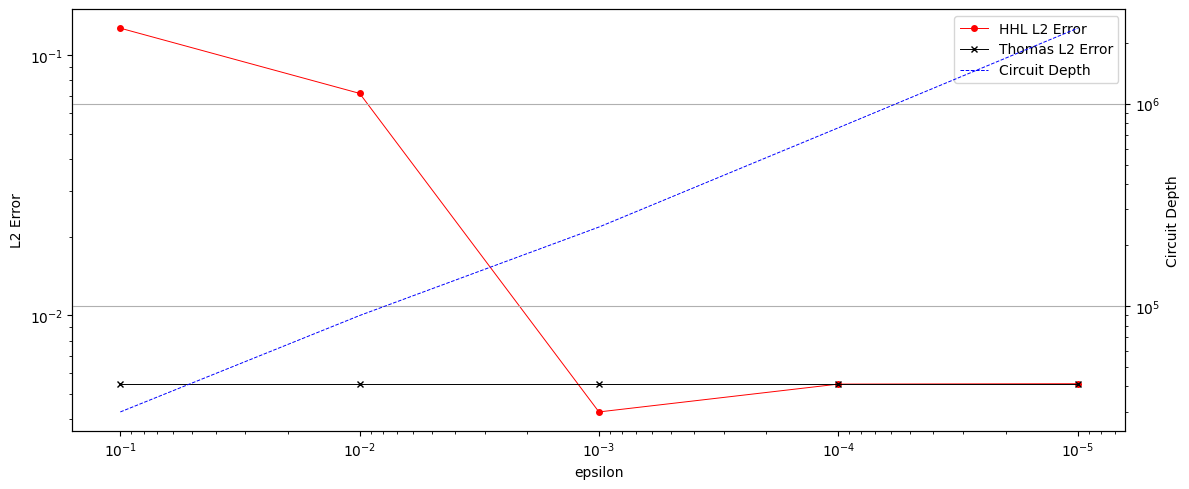

Gradient of the log curve for error convergence HHL (log eps vs log depth): -0.4722


In [233]:
# Plot the error for each wave number on 2 subplots side by side for HHL and Thomas
from pyparsing import line


plt.figure(figsize=(12, 5))

# Subplot for HHL errors
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(eps, [results[k]['L2 error (HHL Statevector)'] for k in eps], 'ro-', label='HHL L2 Error', linewidth=0.7, markersize=4)
ax1.plot(eps, [results[k]['L2 error (Thomas)'] for k in eps], 'kx-', label='Thomas L2 Error', linewidth=0.7, markersize=4)
#ax1.axhline(y=h**2, color='k', linestyle='--', linewidth=0.5, label='h^2')
ax1.set_xlabel('epsilon')
ax1.set_ylabel('L2 Error')
ax1.set_xscale('log')
ax1.set_yscale('log')

# Add circuit depth to a secondary y-axis
ax2 = ax1.twinx()
ax2.plot(eps, [results[k]['depth'] for k in eps], 'b--', label='Circuit Depth', linewidth=0.7, markersize=4)
ax2.set_yscale('log')
ax2.set_ylabel('Circuit Depth')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
plt.gca().invert_xaxis()
plt.grid(True)
#plt.legend()

# Adjust layout for better spacing
plt.tight_layout()
plt.savefig(f'figures/eps_convergence.png', dpi=300)
plt.show()

# compute the gradient 
from scipy.stats import linregress
res = linregress(np.log(eps), np.log([results[k]['depth'] for k in eps]))
print(f"Gradient of the log curve for error convergence HHL (log eps vs log depth): {res.slope:.4f}")

# Condition Number and Error

## Condition number dependence on k

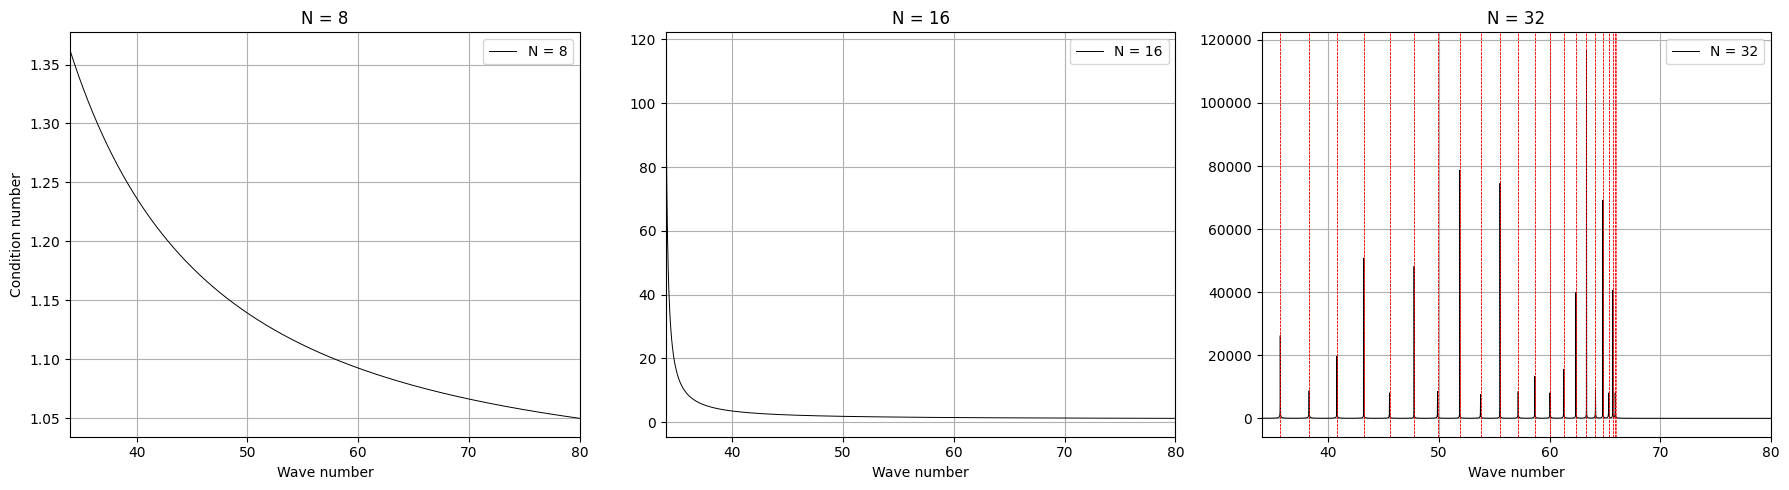

In [257]:
from cProfile import label
from pyparsing import line
from sympy import singularities

L = 1.0
wave_number = np.linspace(34, 80, 5000)
a = -2/h**2 + k**2  # main diagonal
b = 1/h**2          # off diagonal
# Define N values for subplots
N_values = [8, 16, 32]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for i, N in enumerate(N_values):
    h = L / (N + 1)
    a = -2 / h**2 + wave_number**2  # main diagonal
    b = 1 / h**2                    # off diagonal
    condition_numbers = [np.linalg.cond(construct_TT_matrix(-2 / h**2 + k**2, 1 / h**2, N)) for k in wave_number]
    singular_points = [(2/h) * (np.sin( (x * np.pi) /(2 * (N + 1)) )) for x in range(0,100)]
    # Plot condition number vs wave number
    axes[i].plot(wave_number, condition_numbers, 'k-', linewidth=0.7, label=f'N = {N}')
    for sp in singular_points:
        axes[i].axvline(sp, color='r', linestyle='--', linewidth=0.5)
    axes[i].set_xlabel('Wave number')
    axes[i].set_title(f'N = {N}')
    axes[i].grid(True)
    if i == 0:
        axes[i].set_ylabel('Condition number')
    axes[i].legend()
    #axes[i].set_ylim(0, 500)  # Set y-axis limits for better visibility
    axes[i].set_xlim(min(wave_number), max(wave_number))  # Set x-axis limits for better visibility
    #axes[i].set_ylim(0, 100)  # Set y-axis limits for better visibility
plt.tight_layout()
plt.show()

## Smooth Forcing Function

### Run Simulation

Wave number: 34
Matrix Condition number: 116.46119157748751
Eigenvalues: [1146.15845162 1116.9689486  1069.42550445 1005.14715415  926.32281983
  835.63676964  736.17720826  631.33111177  524.66888823  419.82279174
    9.84154838   39.0310514    86.57449555  150.85284585  229.67718017
  320.36323036]
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  8 Number of b qubits :  4
  L2 norm error (Thomas): 0.000004
  L∞ norm error (Thomas): 0.000024
  Mean absolute error (Thomas): 0.000017

  L2 norm error (HHL Statevector): 0.000157
  L∞ norm error (HHL Statevector): 0.000924
  Mean absolute error (HHL Statevector): 0.000617


<Figure size 1200x500 with 0 Axes>

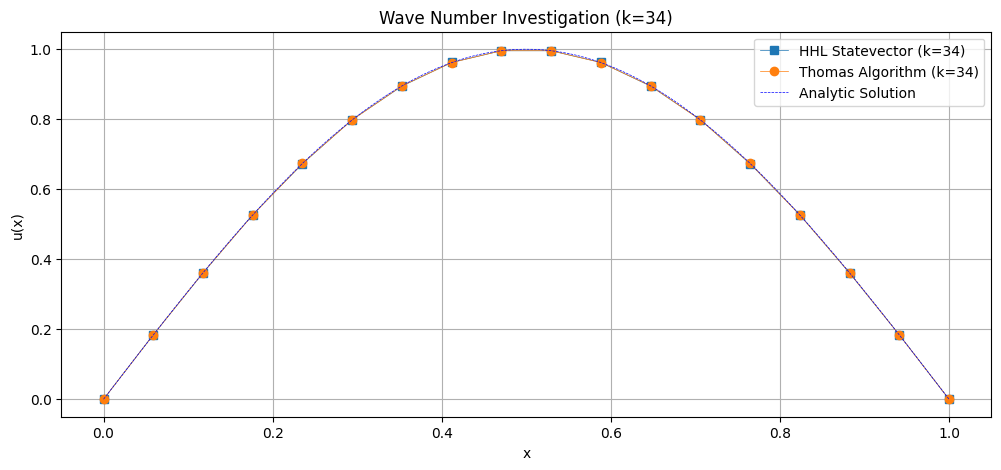

Wave number: 36
Matrix Condition number: 8.583456761487579
Eigenvalues: [ 149.84154838  179.0310514   226.57449555  290.85284585  369.67718017
  460.36323036  559.82279174  664.66888823  771.33111177  876.17720826
 1286.15845162 1256.9689486  1209.42550445 1145.14715415 1066.32281983
  975.63676964]
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
  L2 norm error (Thomas): 0.000004
  L∞ norm error (Thomas): 0.000022
  Mean absolute error (Thomas): 0.000015

  L2 norm error (HHL Statevector): 0.000047
  L∞ norm error (HHL Statevector): 0.000276
  Mean absolute error (HHL Statevector): 0.000182


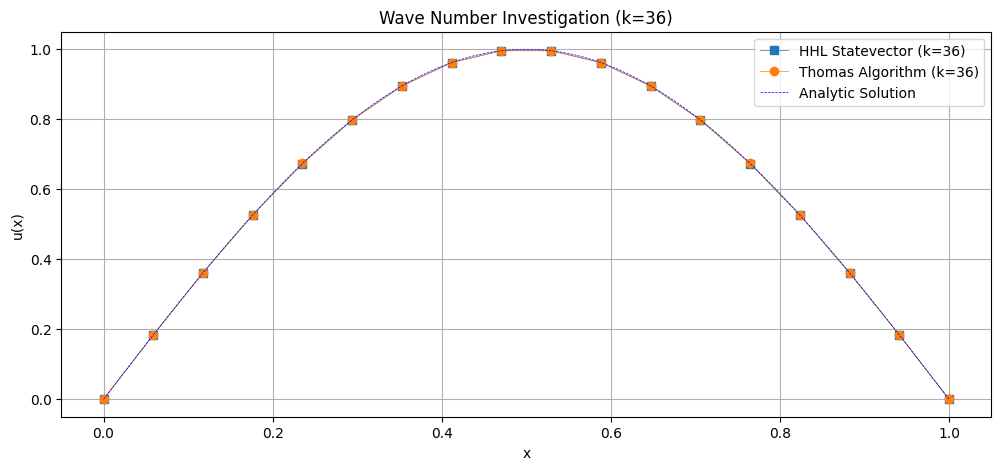

Wave number: 38
Matrix Condition number: 4.815172562071511
Eigenvalues: [ 297.84154838  327.0310514   374.57449555  438.85284585  517.67718017
  608.36323036  707.82279174  812.66888823  919.33111177 1024.17720826
 1434.15845162 1404.9689486  1357.42550445 1293.14715415 1214.32281983
 1123.63676964]
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
  L2 norm error (Thomas): 0.000003
  L∞ norm error (Thomas): 0.000019
  Mean absolute error (Thomas): 0.000013

  L2 norm error (HHL Statevector): 0.000025
  L∞ norm error (HHL Statevector): 0.000151
  Mean absolute error (HHL Statevector): 0.000099


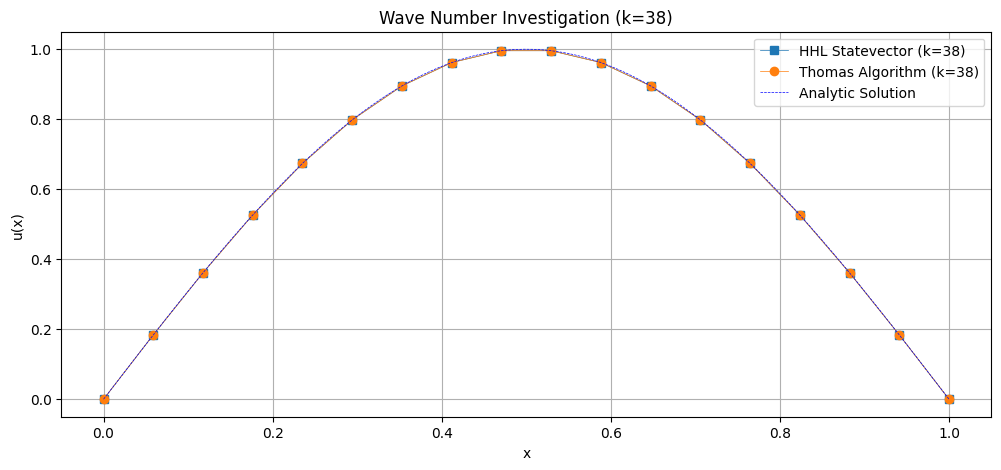

Wave number: 40
Matrix Condition number: 3.5037745162026996
Eigenvalues: [ 453.84154838  483.0310514   530.57449555  594.85284585  673.67718017
  764.36323036  863.82279174  968.66888823 1075.33111177 1180.17720826
 1590.15845162 1560.9689486  1513.42550445 1449.14715415 1370.32281983
 1279.63676964]
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
  L2 norm error (Thomas): 0.000003
  L∞ norm error (Thomas): 0.000018
  Mean absolute error (Thomas): 0.000012

  L2 norm error (HHL Statevector): 0.000017
  L∞ norm error (HHL Statevector): 0.000102
  Mean absolute error (HHL Statevector): 0.000064


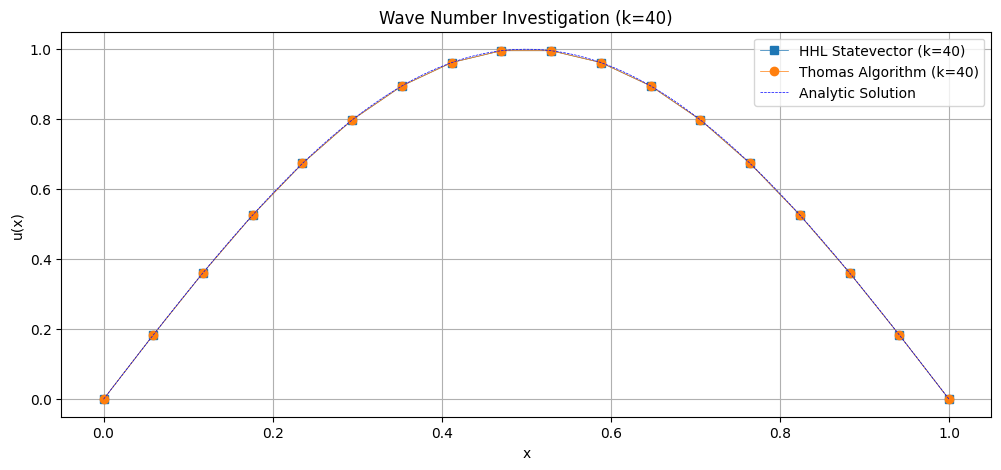

Wave number: 42
Matrix Condition number: 2.839172043720717
Eigenvalues: [ 617.84154838  647.0310514   694.57449555  758.85284585  837.67718017
  928.36323036 1027.82279174 1132.66888823 1239.33111177 1344.17720826
 1754.15845162 1724.9689486  1677.42550445 1613.14715415 1534.32281983
 1443.63676964]
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
  L2 norm error (Thomas): 0.000003
  L∞ norm error (Thomas): 0.000016
  Mean absolute error (Thomas): 0.000011

  L2 norm error (HHL Statevector): 0.000014
  L∞ norm error (HHL Statevector): 0.000094
  Mean absolute error (HHL Statevector): 0.000051


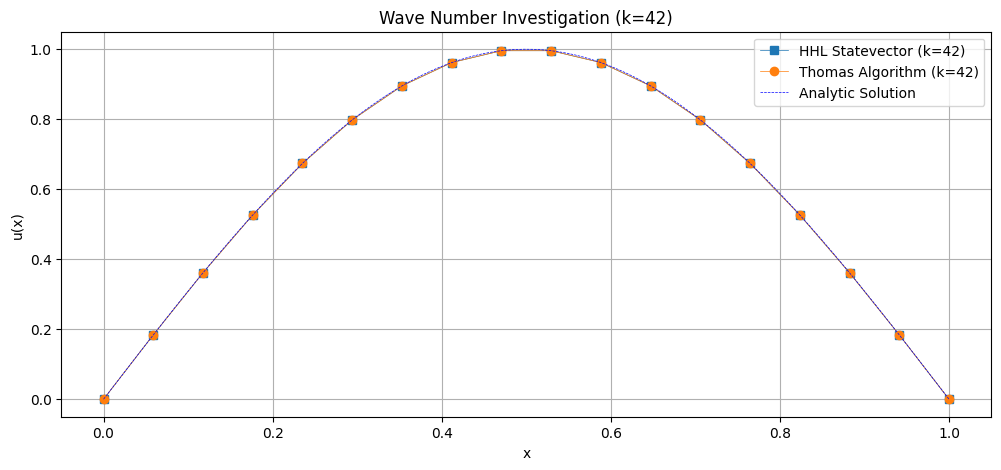

Wave number: 44
Matrix Condition number: 2.438664382193283
Eigenvalues: [ 789.84154838  819.0310514   866.57449555  930.85284585 1009.67718017
 1100.36323036 1199.82279174 1304.66888823 1411.33111177 1516.17720826
 1926.15845162 1896.9689486  1849.42550445 1785.14715415 1706.32281983
 1615.63676964]
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
  L2 norm error (Thomas): 0.000002
  L∞ norm error (Thomas): 0.000015
  Mean absolute error (Thomas): 0.000010

  L2 norm error (HHL Statevector): 0.000006
  L∞ norm error (HHL Statevector): 0.000055
  Mean absolute error (HHL Statevector): 0.000022


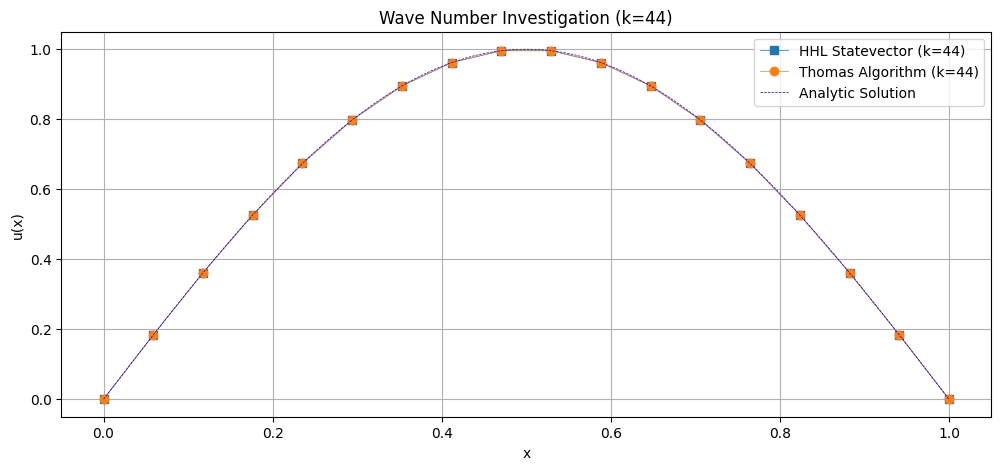

Wave number: 46
Matrix Condition number: 2.171652116914869
Eigenvalues: [ 969.84154838  999.0310514  1046.57449555 1110.85284585 1189.67718017
 1280.36323036 1379.82279174 1484.66888823 1591.33111177 1696.17720826
 2106.15845162 2076.9689486  2029.42550445 1965.14715415 1886.32281983
 1795.63676964]
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
  L2 norm error (Thomas): 0.000002
  L∞ norm error (Thomas): 0.000013
  Mean absolute error (Thomas): 0.000009

  L2 norm error (HHL Statevector): 0.000009
  L∞ norm error (HHL Statevector): 0.000075
  Mean absolute error (HHL Statevector): 0.000029


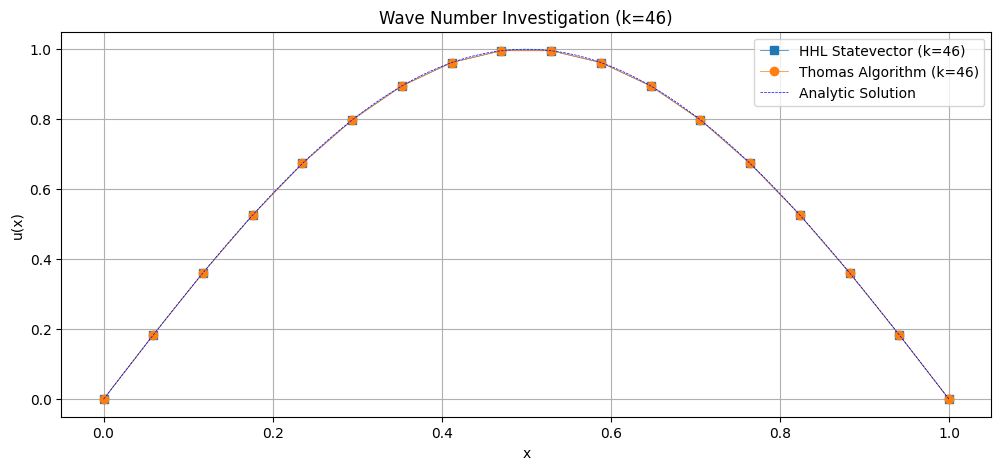

Wave number: 48
Matrix Condition number: 1.9814096797802943
Eigenvalues: [1157.84154838 1187.0310514  1234.57449555 1298.85284585 1377.67718017
 1468.36323036 1567.82279174 1672.66888823 1779.33111177 1884.17720826
 2294.15845162 2264.9689486  2217.42550445 2153.14715415 2074.32281983
 1983.63676964]
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
  L2 norm error (Thomas): 0.000002
  L∞ norm error (Thomas): 0.000012
  Mean absolute error (Thomas): 0.000008

  L2 norm error (HHL Statevector): 0.000010
  L∞ norm error (HHL Statevector): 0.000096
  Mean absolute error (HHL Statevector): 0.000034


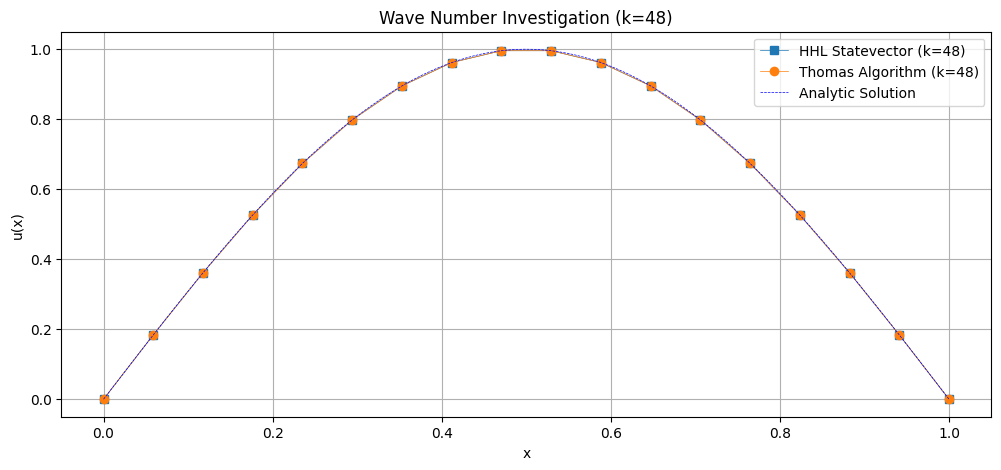

Wave number: 50
Matrix Condition number: 1.8393278405379354
Eigenvalues: [1353.84154838 1383.0310514  1430.57449555 1494.85284585 1573.67718017
 1664.36323036 1763.82279174 1868.66888823 1975.33111177 2080.17720826
 2490.15845162 2460.9689486  2413.42550445 2349.14715415 2270.32281983
 2179.63676964]
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
  L2 norm error (Thomas): 0.000002
  L∞ norm error (Thomas): 0.000011
  Mean absolute error (Thomas): 0.000008

  L2 norm error (HHL Statevector): 0.000007
  L∞ norm error (HHL Statevector): 0.000060
  Mean absolute error (HHL Statevector): 0.000026


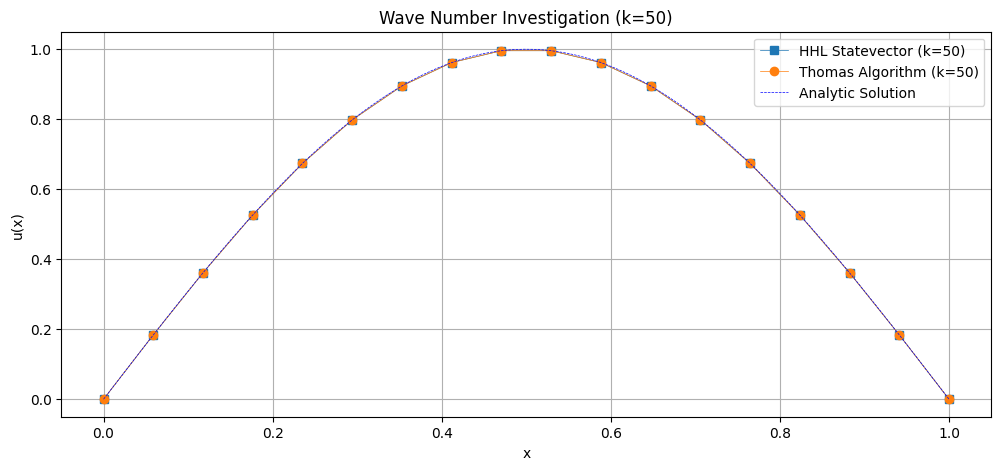

Wave number: 52
Matrix Condition number: 1.7294175100248634
Eigenvalues: [1557.84154838 1587.0310514  1634.57449555 1698.85284585 1777.67718017
 1868.36323036 1967.82279174 2072.66888823 2179.33111177 2284.17720826
 2694.15845162 2664.9689486  2617.42550445 2553.14715415 2474.32281983
 2383.63676964]
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
  L2 norm error (Thomas): 0.000002
  L∞ norm error (Thomas): 0.000010
  Mean absolute error (Thomas): 0.000007

  L2 norm error (HHL Statevector): 0.000009
  L∞ norm error (HHL Statevector): 0.000067
  Mean absolute error (HHL Statevector): 0.000034


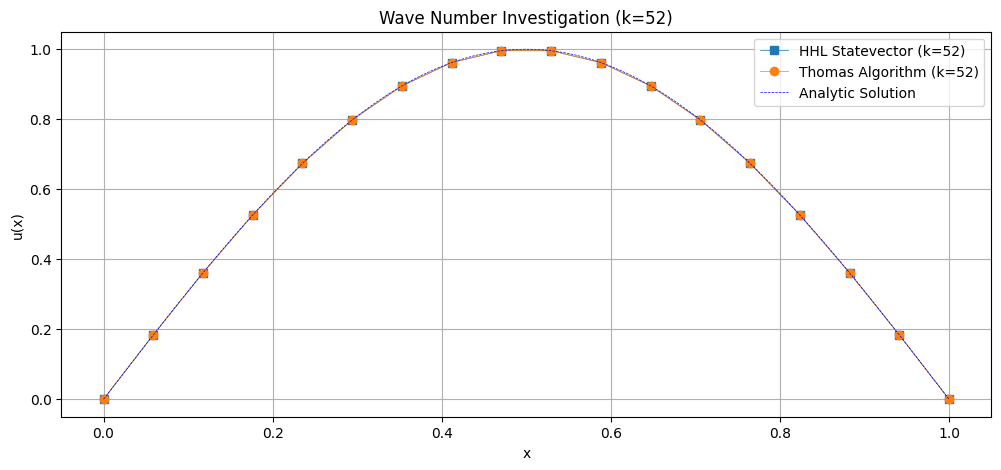

Wave number: 54
Matrix Condition number: 1.6420444272386785
Eigenvalues: [1769.84154838 1799.0310514  1846.57449555 1910.85284585 1989.67718017
 2080.36323036 2179.82279174 2284.66888823 2391.33111177 2496.17720826
 2906.15845162 2876.9689486  2829.42550445 2765.14715415 2686.32281983
 2595.63676964]
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
  L2 norm error (Thomas): 0.000002
  L∞ norm error (Thomas): 0.000010
  Mean absolute error (Thomas): 0.000007

  L2 norm error (HHL Statevector): 0.000011
  L∞ norm error (HHL Statevector): 0.000103
  Mean absolute error (HHL Statevector): 0.000036


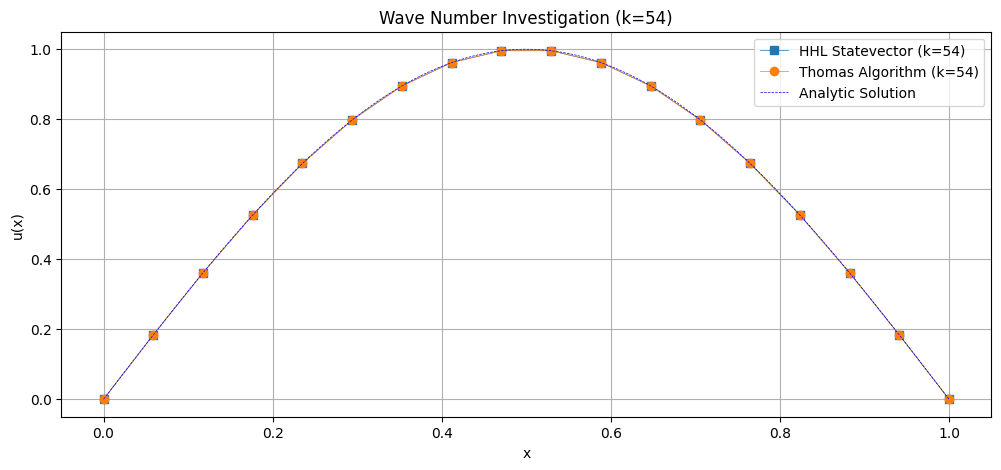

Wave number: 56
Matrix Condition number: 1.5710589891733646
Eigenvalues: [1989.84154838 2019.0310514  2066.57449555 2130.85284585 2209.67718017
 2300.36323036 2399.82279174 2504.66888823 2611.33111177 2716.17720826
 3126.15845162 3096.9689486  3049.42550445 2985.14715415 2906.32281983
 2815.63676964]
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
  L2 norm error (Thomas): 0.000002
  L∞ norm error (Thomas): 0.000009
  Mean absolute error (Thomas): 0.000006

  L2 norm error (HHL Statevector): 0.000010
  L∞ norm error (HHL Statevector): 0.000079
  Mean absolute error (HHL Statevector): 0.000035


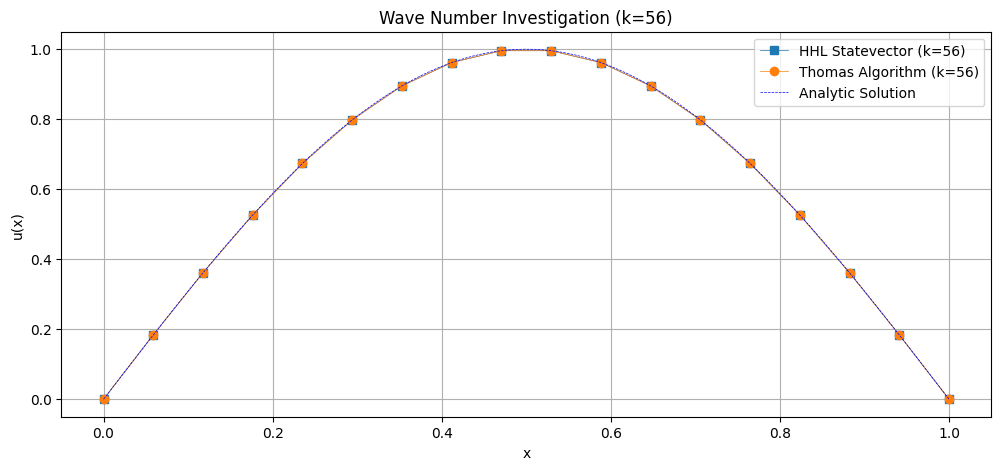

Wave number: 58
Matrix Condition number: 1.51235260880707
Eigenvalues: [2217.84154838 2247.0310514  2294.57449555 2358.85284585 2437.67718017
 2528.36323036 2627.82279174 2732.66888823 2839.33111177 2944.17720826
 3354.15845162 3324.9689486  3277.42550445 3213.14715415 3134.32281983
 3043.63676964]
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
  L2 norm error (Thomas): 0.000001
  L∞ norm error (Thomas): 0.000008
  Mean absolute error (Thomas): 0.000006

  L2 norm error (HHL Statevector): 0.000007
  L∞ norm error (HHL Statevector): 0.000046
  Mean absolute error (HHL Statevector): 0.000026


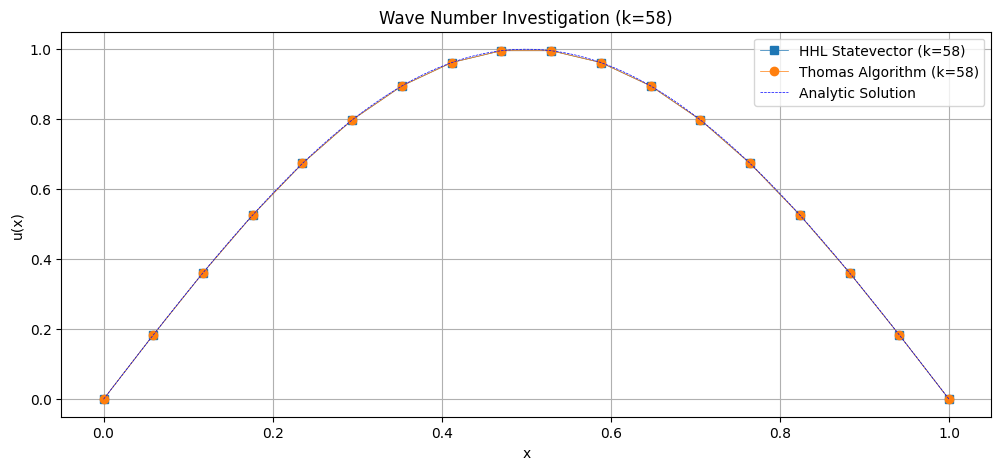

Wave number: 60
Matrix Condition number: 1.463076723101181
Eigenvalues: [2453.84154838 2483.0310514  2530.57449555 2594.85284585 2673.67718017
 2764.36323036 2863.82279174 2968.66888823 3075.33111177 3180.17720826
 3590.15845162 3560.9689486  3513.42550445 3449.14715415 3370.32281983
 3279.63676964]
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
  L2 norm error (Thomas): 0.000001
  L∞ norm error (Thomas): 0.000008
  Mean absolute error (Thomas): 0.000005

  L2 norm error (HHL Statevector): 0.000017
  L∞ norm error (HHL Statevector): 0.000157
  Mean absolute error (HHL Statevector): 0.000055


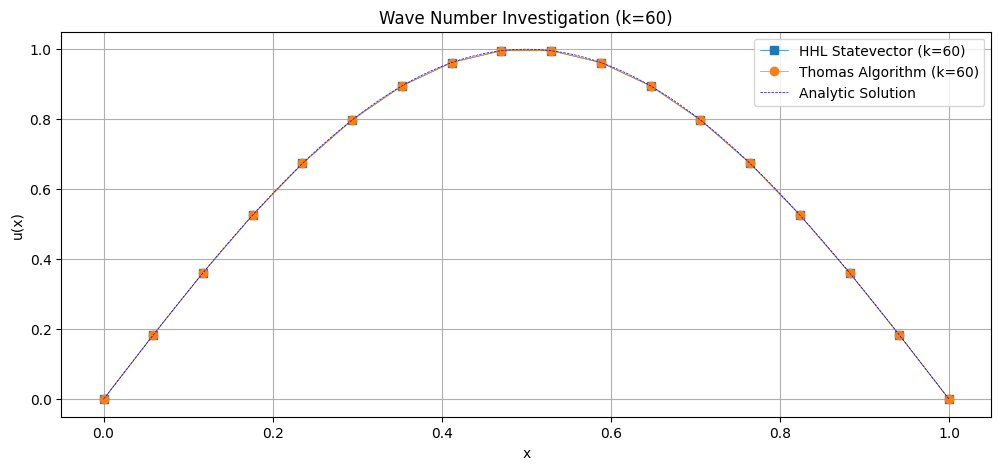

Wave number: 62
Matrix Condition number: 1.421194826625673
Eigenvalues: [2697.84154838 2727.0310514  2774.57449555 2838.85284585 2917.67718017
 3008.36323036 3107.82279174 3212.66888823 3319.33111177 3424.17720826
 3834.15845162 3804.9689486  3757.42550445 3693.14715415 3614.32281983
 3523.63676964]
0
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  4
  L2 norm error (Thomas): 0.000001
  L∞ norm error (Thomas): 0.000007
  Mean absolute error (Thomas): 0.000005

  L2 norm error (HHL Statevector): 0.000011
  L∞ norm error (HHL Statevector): 0.000071
  Mean absolute error (HHL Statevector): 0.000043


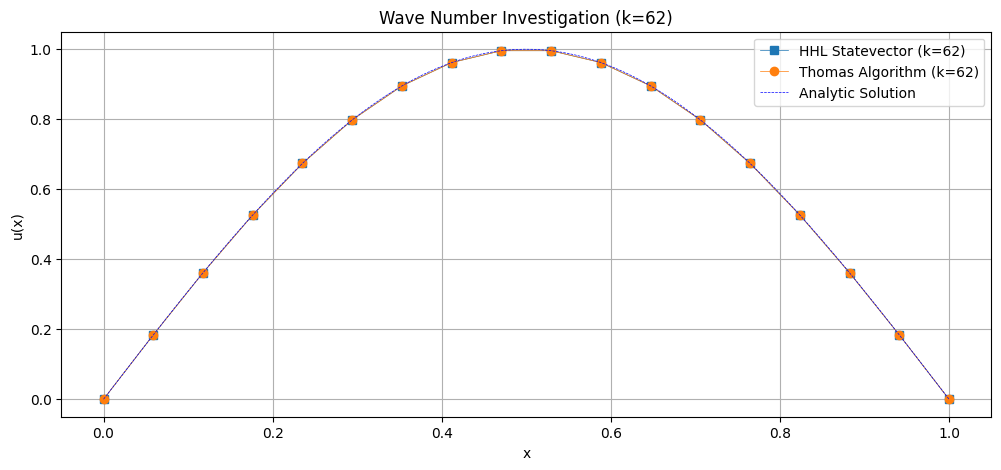

In [258]:

# Build the matrix A
from re import U


NUM_QUBITS = 4
MATRIX_SIZE = 2 ** NUM_QUBITS


# Plot the results for each qubit number on a single graph
plt.figure(figsize=(12, 5))
# Loop over different qubit numbers
MATRIX_SIZE = 2 ** NUM_QUBITS
L = 1.0                                     # Domain length
N = MATRIX_SIZE                             # No. of points
h = L / (N+1)                               # Step size
eps = 0.001                                  # Error tolerance
numShots = 10000                             # Number of shots for QASM simulation
x_numerical = np.linspace(0, L, N+2)[1:-1]  # Interior points
x_fine = np.linspace(0, L, 200)

u_error = np.sin(np.pi * x_numerical)

# Loop over different wave numbers
#wave_numbers = np.arange(3.3, 4.9, 0.1)  # Define a range of wave numbers to investigate#[3.8, 3.9, 4]  # Define a range of wave numbers to investigate
wave_numbers = np.arange(34, 64, 2)   # Define a range of wave numbers to investigate
results = {}

for k in wave_numbers:
    print(f"Wave number: {k}")
    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off diagonal

    matrix = construct_TT_matrix(a, b, N)  # Construct the tridiagonal Toeplitz matrix
    print(f"Matrix Condition number: {np.linalg.cond(matrix)}")
    vector = (k**2 - np.pi**2) * np.sin(np.pi * x_numerical)
    #print the eigenvalues of the matrix
    eigenvalues = np.linalg.eigvals(matrix)
    
    print(f"Eigenvalues: {eigenvalues}")
    # reciprocal eigenvalue spectrum
    spectrum = max(1/eigenvalues) - min(1/eigenvalues)
    
    hhl_solution_obj = solve_1DHHL(matrix, vector, NUM_QUBITS, eps)
    hhl_norm = hhl_solution_obj.euclidean_norm
    solution_hhl = statevector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, vector, numShots)

    # psi_norm = np.linalg.norm(solution_hhl)
    # x_phys = (hhl_norm / psi_norm) * solution_hhl
    # x_phys = x_phys * np.linalg.norm(vector)
    
    
    # Compare to thomas
    num_solution = solve_1DThomas(matrix, vector)
    num_solution = np.concatenate(([0], num_solution, [0]))
    
    x_phys = solution_hhl * np.linalg.norm(num_solution)/ np.linalg.norm(solution_hhl)
    u_error = u_error 
    num_solution = num_solution 
    hhl_vector_sv = np.concatenate(([0], x_phys, [0]))


    
    # Get the L2 and Linf errors
    num_diff = num_solution[1:len(num_solution)-1] - u_error
    E2_thomas = np.sqrt(h**2 * np.sum(num_diff**2))
    Einf_thomas = np.max(np.abs(num_diff))
    mae_thomas = np.mean(np.abs(num_diff))

    
    hhl_diff = hhl_vector_sv[1:len(hhl_vector_sv)-1] - u_error
    E2_hhl = np.sqrt(h**2 * np.sum(hhl_diff**2))
    Einf_hhl = np.max(np.abs(hhl_diff))
    mae_hhl = np.mean(np.abs(hhl_diff))

    print(f"  L2 norm error (Thomas): {E2_thomas:.6f}")
    print(f"  L∞ norm error (Thomas): {Einf_thomas:.6f}")
    print(f"  Mean absolute error (Thomas): {mae_thomas:.6f}")
    print()
    print(f"  L2 norm error (HHL Statevector): {E2_hhl:.6f}")
    print(f"  L∞ norm error (HHL Statevector): {Einf_hhl:.6f}")
    print(f"  Mean absolute error (HHL Statevector): {mae_hhl:.6f}")
    
    # Store results for each wave number
    results[k] = {
        'L2 error (Thomas)': E2_thomas,
        'L∞ error (Thomas)': Einf_thomas,
        'Mean absolute error (Thomas)': mae_thomas,
        'L2 error (HHL Statevector)': E2_hhl,
        'L∞ error (HHL Statevector)': Einf_hhl,
        'Mean absolute error (HHL Statevector)': mae_hhl,
        "condition": np.linalg.cond(matrix),
        "spectrum": spectrum,
        'max': 1/np.max(np.abs(eigenvalues))
    }

    # Plot the results
    plt.figure(figsize=(12, 5))
    plt.plot(np.concatenate(([0], x_numerical, [L])), hhl_vector_sv, 's-', linewidth=0.5, label=f'HHL Statevector (k={k})')
    plt.plot(np.concatenate(([0], x_numerical, [L])), num_solution, 'o-', linewidth=0.5, label=f'Thomas Algorithm (k={k})')
    plt.plot(x_fine, np.sin(np.pi * x_fine), 'b--', linewidth=0.5, label='Analytic Solution')
    plt.xlabel('x')
    plt.ylabel('u(x)')
    plt.title(f'Wave Number Investigation (k={k})')
    plt.legend()
    plt.grid(True)
    plt.show()


### Plot Results

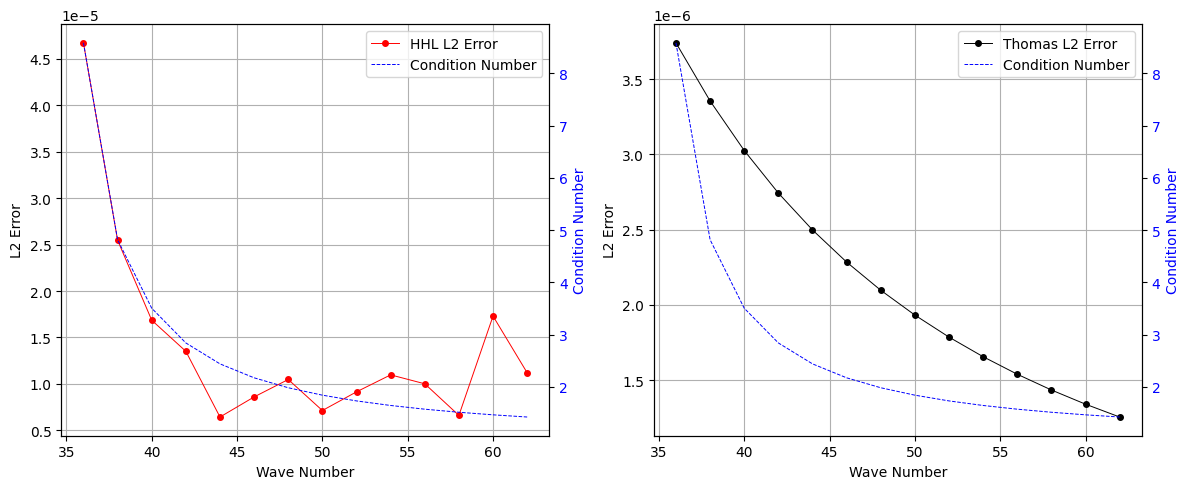

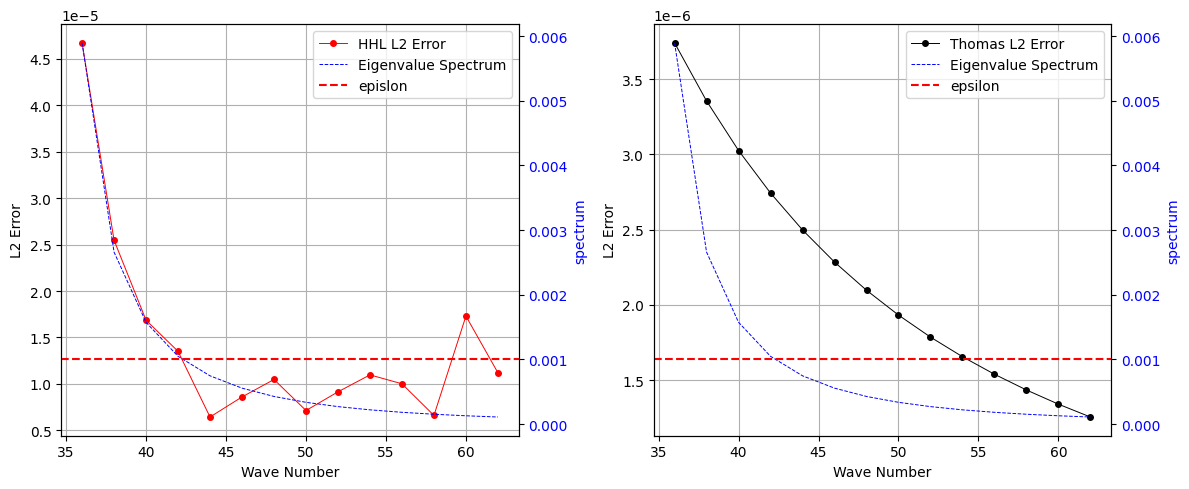

In [261]:
# Plot the error for each wave number on 2 subplots side by side for HHL and Thomas
#wave_numbers = np.arange(3.4, 4.9, 0.1)
wave_numbers = np.arange(34, 64, 2)   # Define a range of wave numbers to investigate
wave_numbers = wave_numbers[1:]
plt.figure(figsize=(12, 5))
# Subplot for HHL errors
ax1 = plt.subplot(1, 2, 1)
line1, = ax1.plot(wave_numbers, [results[k]['L2 error (HHL Statevector)'] for k in wave_numbers], 'ro-', linewidth=0.7, markersize=4, label='HHL L2 Error')
#ax1.plot(wave_numbers, [results[k]['L∞ error (HHL Statevector)'] for k in wave_numbers], 'rx-', label='HHL L∞ Error')
ax1.set_xlabel('Wave Number')
ax1.set_ylabel('L2 Error')
#ax1.set_title('HHL Error vs Wave Number')
ax1.grid(True)

# Add secondary y-axis for condition number
ax1_cond = ax1.twinx()
line2, = ax1_cond.plot(wave_numbers, [results[k]['condition'] for k in wave_numbers], 'b--', linewidth=0.7, markersize=4, label='Condition Number')
ax1_cond.set_ylabel('Condition Number', color='b')
ax1_cond.tick_params(axis='y', labelcolor='b')

# Combine legends from both axes
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right')

# Subplot for Thomas errors
ax2 = plt.subplot(1, 2, 2)
line3, = ax2.plot(wave_numbers, [results[k]['L2 error (Thomas)'] for k in wave_numbers], 'ko-', linewidth=0.7, markersize=4, label='Thomas L2 Error')
#ax2.plot(wave_numbers, [results[k]['L∞ error (Thomas)'] for k in wave_numbers], 'kx-', label='Thomas L∞ Error')
ax2.set_xlabel('Wave Number')
ax2.set_ylabel('L2 Error')
#ax2.set_title('Thomas Error vs Wave Number')
ax2.grid(True)

# Add secondary y-axis for condition number
ax2_cond = ax2.twinx()
line4, = ax2_cond.plot(wave_numbers, [results[k]['condition'] for k in wave_numbers], 'b--',  linewidth=0.7, markersize=4,label='Condition Number')
ax2_cond.set_ylabel('Condition Number', color='b')
ax2_cond.tick_params(axis='y', labelcolor='b')

# Combine legends from both axes
lines2 = [line3, line4]
labels2 = [line.get_label() for line in lines2]
ax2.legend(lines2, labels2, loc='upper right')

# Adjust layout for better spacing
plt.tight_layout()
plt.savefig(f'figures/condition_number_convergence_big_k.png', dpi=300)
plt.show()

# Plot the error for each wave number on 2 subplots side by side for HHL and Thomas
plt.figure(figsize=(12, 5))

# Subplot for HHL errors
ax1 = plt.subplot(1, 2, 1)
line1, = ax1.plot(wave_numbers, [results[k]['L2 error (HHL Statevector)'] for k in wave_numbers], 'ro-',  linewidth=0.7, markersize=4, label='HHL L2 Error')
#ax1.plot(wave_numbers, [results[k]['L∞ error (HHL Statevector)'] for k in wave_numbers], 'rx-', label='HHL L∞ Error')
ax1.set_xlabel('Wave Number')
ax1.set_ylabel('L2 Error')
#ax1.set_title('HHL Error vs Wave Number')
ax1.grid(True)

# Add secondary y-axis for spectrum
ax1_cond = ax1.twinx()
line2, = ax1_cond.plot(wave_numbers, [results[k]['spectrum'] for k in wave_numbers], 'b--',  linewidth=0.7, markersize=4, label='Eigenvalue Spectrum')
line3 = ax1_cond.axhline(eps, color='r', linestyle='--', label='epislon')
ax1_cond.set_ylabel('spectrum', color='b')
ax1_cond.tick_params(axis='y', labelcolor='b')

# Combine legends from both axes into one
lines = [line1, line2, line3]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right')

# Subplot for Thomas errors
ax2 = plt.subplot(1, 2, 2)
line5, = ax2.plot(wave_numbers, [results[k]['L2 error (Thomas)'] for k in wave_numbers], 'ko-',  linewidth=0.7, markersize=4, label='Thomas L2 Error')
#ax2.plot(wave_numbers, [results[k]['L∞ error (Thomas)'] for k in wave_numbers], 'kx-', label='Thomas L∞ Error')
ax2.set_xlabel('Wave Number')
ax2.set_ylabel('L2 Error')
#ax2.set_title('Thomas Error vs Wave Number')
ax2.grid(True)

# Add secondary y-axis for spectrum
ax2_cond = ax2.twinx()
line6, = ax2_cond.plot(wave_numbers, [results[k]['spectrum'] for k in wave_numbers], 'b--',  linewidth=0.7, markersize=4, label='Eigenvalue Spectrum')
line7 = ax2_cond.axhline(eps, color='r', linestyle='--', label='epsilon')
ax2_cond.set_ylabel('spectrum', color='b')
ax2_cond.tick_params(axis='y', labelcolor='b')

# Combine legends from both axes into one
lines2 = [line5, line6, line7]
labels2 = [line.get_label() for line in lines2]
ax2.legend(lines2, labels2, loc='upper right')

# Adjust layout for better spacing
plt.tight_layout()
plt.savefig(f'figures/spectrum_number_convergence_big_k.png', dpi=300)
plt.show()



## Step Forcing Function

# Preconditioners

## Condition Number vs wave number and optimal shift parameter investigation
Perform tests for a large wave number and with thomas algorithm

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.sparse import diags
import pandas as pd

def compute_matrix_condition_number(k, N, L=1.0, shifted=False, alpha=0.5):
    """Compute condition number using matrix approach like in second code."""
    h = L / (N + 1)
    
    if shifted:
        # Complex shifted Laplacian: -Δ - (1+αi)k²
        a = -2 / h**2 + (1 - 1j * alpha) * k**2
    else:
        # Original Helmholtz operator: -Δ - k²
        a = -2 / h**2 + k**2
        
    b = 1 / h**2
    
    # Create tridiagonal matrix
    M = diags([b, a, b], [-1, 0, 1], shape=(N, N)).toarray()
    
    # Calculate condition number
    cond = np.linalg.cond(M)
    return cond

def find_stabilization_point(N, L=1.0, shifted=False, alpha=0.5, k_range=None, 
                             stability_threshold=0.01, window_size=3):
    """
    Find where the condition number stabilizes (stops changing significantly)
    
    Parameters:
    - N: Dimension
    - L: Domain length
    - shifted: Whether to use complex shifted Laplacian
    - alpha: Complex shift parameter (if shifted=True)
    - k_range: Range of k values to test
    - stability_threshold: Threshold for considering the condition number stable
    - window_size: Number of consecutive points to check for stability
    
    Returns:
    - stabilization_k: k value where condition number stabilizes
    - condition_numbers: Dictionary with k values and condition numbers
    """
    if k_range is None:
        k_range = np.linspace(5, 70, 200)  # Adjusted to match second code range
    
    # Calculate condition numbers for each k in the range
    condition_numbers = {}
    for k in k_range:
        condition_numbers[k] = compute_matrix_condition_number(k, N, L, shifted, alpha)
    
    # Find where the rate of change falls below the threshold
    stabilization_k = None
    
    for i in range(len(k_range) - window_size):
        k_values = k_range[i:i+window_size]
        cond_values = [condition_numbers[k] for k in k_values]
        
        # Calculate percentage changes between consecutive points
        changes = [abs(cond_values[j+1] - cond_values[j])/cond_values[j] for j in range(window_size-1)]
        
        # If all changes in the window are below threshold, consider it stabilized
        if all(change < stability_threshold for change in changes):
            stabilization_k = k_values[0]
            break
    
    return stabilization_k, condition_numbers

# Parameters
ALPHA = 0.5  # Complex shift parameter (typical values are between 0.2 and 0.5)
L = 1.0

# Use N values similar to the original code, but also add the powers of 2 from second code
N_values = [4, 8, 16]
N_values_shifted = [4, 8, 16]  # Comparable to 2^3, 2^4, 2^5 in second code

# Store results for both original and shifted methods
results_original = []
results_shifted = []

# Original system analysis
print("Original Helmholtz Operator Results:")
print("-" * 80)
for N in N_values:
    # Find the stabilization point
    k_range = np.linspace(5, 70, 200)
    stabilization_k, condition_numbers = find_stabilization_point(N, L, shifted=False, k_range=k_range)
    
    # Find condition number at stabilization point
    if stabilization_k is not None:
        stable_cond = condition_numbers[stabilization_k]
    else:
        stable_cond = None
    
    results_original.append({
        'N': N,
        'stabilization_k': stabilization_k,
        'stable_condition_number': stable_cond
    })
    
    print(f"N = {N}:")
    if stabilization_k is not None:
        print(f"  Stabilization occurs at k ≈ {stabilization_k:.4f}")
        print(f"  Condition number at stabilization point: {stable_cond:.4f}")
    else:
        print(f"  No clear stabilization found in the provided k range")
    print()

# Summary table for original system
print("Summary table (Original):")
print("-" * 80)
print(f"{'N':>3} | {'Stabilization k':>15} | {'Stable Condition Number':>25}")
print("-" * 80)
for r in results_original:
    stabilization_k = r['stabilization_k']
    stable_cond = r['stable_condition_number']
    
    if stabilization_k is not None:
        print(f"{r['N']:>3} | {stabilization_k:>15.4f} | {stable_cond:>25.4f}")
    else:
        print(f"{r['N']:>3} | {'Not found':>15} | {'N/A':>25}")
print()

# Complex Shifted system analysis
print("Complex Shifted Laplacian Results:")
print("-" * 80)
for N in N_values_shifted:
    # Find the stabilization point for shifted system
    k_range = np.linspace(5, 70, 200)
    stabilization_k, condition_numbers = find_stabilization_point(N, L, shifted=True, alpha=ALPHA, k_range=k_range)
    
    # Find condition number at stabilization point
    if stabilization_k is not None:
        stable_cond = condition_numbers[stabilization_k]
    else:
        stable_cond = None
    
    results_shifted.append({
        'N': N,
        'stabilization_k': stabilization_k,
        'stable_condition_number': stable_cond
    })
    
    print(f"N = {N} (Shifted, α = {ALPHA}):")
    if stabilization_k is not None:
        print(f"  Stabilization occurs at k ≈ {stabilization_k:.4f}")
        print(f"  Condition number at stabilization point: {stable_cond:.4f}")
    else:
        print(f"  No clear stabilization found in the provided k range")
    print()

# Summary table for shifted system
print("Summary table (Shifted):")
print("-" * 80)
print(f"{'N':>3} | {'Stabilization k':>15} | {'Stable Condition Number':>25}")
print("-" * 80)
for r in results_shifted:
    stabilization_k = r['stabilization_k']
    stable_cond = r['stable_condition_number']
    
    if stabilization_k is not None:
        print(f"{r['N']:>3} | {stabilization_k:>15.4f} | {stable_cond:>25.4f}")
    else:
        print(f"{r['N']:>3} | {'Not found':>15} | {'N/A':>25}")
print()

# Create comparison plots
plt.figure(figsize=(12, 8))

# Plot condition number vs k for original system
for result in results_original:
    N = result['N']
    k_range = np.linspace(5, 70, 300)
    cond_values = [compute_matrix_condition_number(k, N, L, shifted=False) for k in k_range]
    
    # Find the stabilization point
    stabilization_k = result['stabilization_k']
    
    plt.plot(k_range, cond_values, label=f'Original N = {N}')
    
    if stabilization_k is not None:
        plt.axvline(x=stabilization_k, linestyle='--', color='gray', alpha=0.5)
        plt.text(stabilization_k+1, min(cond_values)+1, f'k ≈ {stabilization_k:.2f}', 
                 rotation=90, verticalalignment='bottom')

# Add shifted system for comparison (for smaller N values)
for result in results_shifted:
    N = result['N']
    k_range = np.linspace(5, 70, 300)
    cond_values = [compute_matrix_condition_number(k, N, L, shifted=True, alpha=ALPHA) for k in k_range]
    
    # Find the stabilization point
    stabilization_k = result['stabilization_k']
    
    plt.plot(k_range, cond_values, linestyle='--', label=f'Shifted N = {N}')
    
    if stabilization_k is not None:
        plt.axvline(x=stabilization_k, linestyle=':', color='red', alpha=0.5)
        plt.text(stabilization_k+1, min(cond_values)*1.5, f'k ≈ {stabilization_k:.2f}', 
                 rotation=90, verticalalignment='bottom', color='red')

plt.title('Condition Number vs. Wave Number (k)')
plt.xlabel('Wave Number (k)')
plt.ylabel('Condition Number')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)  # Start y-axis at 0
plt.tight_layout()
plt.savefig('condition_comparison.png')
plt.show()

# Create log-scale plot for better visualization of both systems
plt.figure(figsize=(12, 8))

# Plot condition number vs k for original system (log scale)
for result in results_original:
    N = result['N']
    k_range = np.linspace(5, 70, 300)
    cond_values = [compute_matrix_condition_number(k, N, L, shifted=False) for k in k_range]
    
    plt.plot(k_range, cond_values, label=f'Original N = {N}')

# Add shifted system for comparison
for result in results_shifted:
    N = result['N']
    k_range = np.linspace(5, 70, 300)
    cond_values = [compute_matrix_condition_number(k, N, L, shifted=True, alpha=ALPHA) for k in k_range]
    
    plt.plot(k_range, cond_values, linestyle='--', label=f'Shifted N = {N}')

plt.title('Condition Number vs. Wave Number (k) - Log Scale')
plt.xlabel('Wave Number (k)')
plt.ylabel('Condition Number (log scale)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('condition_comparison_log.png')
plt.show()

# Create individual plots for each system and dimension
# Original system
fig, axs = plt.subplots(1, len(results_original), figsize=(20, 6), sharey=True)

for ax, (r_orig, r_shift) in zip(axs, zip(results_original, results_shifted)):
    stabilization_k = r_orig['stabilization_k']
    N = r_orig['N']
    k_range = np.linspace(5, 70, 300)
    cond_values = [compute_matrix_condition_number(k, N, L, shifted=False) for k in k_range]   
     
    ax.plot(k_range, cond_values, 'b-', label='Original')
    
    # Mark stabilization point
    if stabilization_k is not None:
        ax.axvline(x=stabilization_k, color='green', linestyle='--', 
                  label=f'Stabilization (k ≈ {stabilization_k:.2f})')
            
    stabilization_k = r_shift['stabilization_k']
    N = r_shift['N']
    cond_values = [compute_matrix_condition_number(k, N, L, shifted=True, alpha=ALPHA) for k in k_range]   
     
    ax.plot(k_range, cond_values, 'g-', label=f'Complex Shifted (α = {ALPHA})')
    
    # Mark stabilization point
    if stabilization_k is not None:
        ax.axvline(x=stabilization_k, color='red', linestyle='--', 
                  label=f'Shifted Stabilization (k ≈ {stabilization_k:.2f})')
    
    ax.set_title(f'N = {N}')
    ax.set_xlabel('Wave Number')
    ax.set_yscale('log')
    ax.grid(True)
    if ax == axs[0]:
        ax.set_ylabel('Condition Number (log)')
    ax.legend()

plt.tight_layout()
plt.savefig('figures/condition_vs_wavenumber_shifted_subplot.png')
plt.show()
    
    
# Shifted system
# Merged summary table with percentage difference
print("Merged Summary Table with Percentage Difference:")
print("-" * 100)
print(f"{'N':>3} | {'Stabilization k (Original)':>25} | {'Stable Condition Number (Original)':>30} | {'Stabilization k (Shifted)':>25} | {'Stable Condition Number (Shifted)':>30} | {'% Diff':>10}")
print("-" * 100)
for r_orig, r_shift in zip(results_original, results_shifted):
    N = r_orig['N']
    stabilization_k_orig = r_orig['stabilization_k']
    stable_cond_orig = r_orig['stable_condition_number']
    stabilization_k_shift = r_shift['stabilization_k']
    stable_cond_shift = r_shift['stable_condition_number']
    
    if stabilization_k_orig is not None and stable_cond_orig is not None and stabilization_k_shift is not None and stable_cond_shift is not None:
        pct_diff = -(abs(stable_cond_shift - stable_cond_orig) / stable_cond_orig) * 100
        print(f"{N:>3} | {stabilization_k_orig:>25.4f} | {stable_cond_orig:>30.4f} | {stabilization_k_shift:>25.4f} | {stable_cond_shift:>30.4f} | {pct_diff:>10.2f}%")
    else:
        print(f"{N:>3} | {'Not found':>25} | {'N/A':>30} | {'Not found':>25} | {'N/A':>30} | {'N/A':>10}")
        
        


In [ ]:


ALPHA = 0.5  # Complex shift parameter (typical values are between 0.2 and 0.5)
NUM_QUBITS_LIST = [3, 4, 5]
k_vals = list(range(5, 70))

# Dictionary to store computed data for each qubit count
results = {}

for num_qubits in NUM_QUBITS_LIST:
    MATRIX_SIZE = 2 ** num_qubits
    L = 2.0
    N = MATRIX_SIZE
    h = L / (N + 1)

    cond_original = []
    cond_shifted = []
    cond_precond = []
    clock_qubits_original = []
    clock_qubits_shifted = []

    nb = num_qubits  # Base number of qubits for the b-vector
    neg_vals = 1

    for kk in k_vals:
        # Original Helmholtz operator: -Δ - k²
        a_orig = -2 / h**2 + kk**2
        b_orig = 1 / h**2
        M_orig = diags([b_orig, a_orig, b_orig], [-1, 0, 1], shape=(N, N)).toarray()

        # Complex shifted Laplacian: -Δ - (1+αi)k²
        a_shifted = -2 / h**2 + (1 - 1j * ALPHA) * kk**2
        b_shifted = 1 / h**2
        M_shifted = diags([b_shifted, a_shifted, b_shifted], [-1, 0, 1], shape=(N, N)).toarray()

        # Compute condition numbers
        c_orig = np.linalg.cond(M_orig)
        cond_original.append(c_orig)

        c_shifted = np.linalg.cond(M_shifted)
        cond_shifted.append(c_shifted)

        # Jacobi Preconditioner for the shifted system
        diag_elements = np.diag(M_shifted)
        D_inv = np.diag(1.0 / diag_elements)
        prec_matrix = D_inv @ M_shifted
        c_prec = np.linalg.cond(prec_matrix)
        cond_precond.append(c_prec)

        # Estimate clock qubits needed for both systems
        n_l_orig = max(nb + 1, int(np.ceil(np.log2(c_orig + 1)))) + neg_vals
        clock_qubits_original.append(n_l_orig)

        n_l_shifted = max(nb + 1, int(np.ceil(np.log2(c_shifted + 1)))) + neg_vals
        clock_qubits_shifted.append(n_l_shifted)

    # Save computed data for this number of qubits
    results[num_qubits] = {
        'N': N,
        'cond_original': cond_original,
        'cond_shifted': cond_shifted,
        'cond_precond': cond_precond,
        'clock_qubits_original': clock_qubits_original,
        'clock_qubits_shifted': clock_qubits_shifted
    }

# Plot condition numbers and clock qubits for each system
fig, axs = plt.subplots(1, len(NUM_QUBITS_LIST), figsize=(18, 5))
for idx, num_qubits in enumerate(NUM_QUBITS_LIST):
    res = results[num_qubits]
    ax1 = axs[idx]
    ax1.plot(k_vals, res['cond_original'], 'b-', linewidth=0.7, label='Original')
    ax1.plot(k_vals, res['cond_shifted'], 'gx-', linewidth=0.7, label=f'Shifted (α={ALPHA})')
    #ax1.plot(k_vals, res['cond_precond'], 'm-', linewidth=0.7, label='Precond. Shifted')
    ax1.set_xlabel('Wave Number')
    ax1.set_title(f'N = {res["N"]}')
    if idx == 0:
        ax1.set_ylabel('Condition Number')

    ax2 = ax1.twinx()
    ax2.plot(k_vals, res['clock_qubits_original'], 'r-', linewidth=0.5, label='Original Qubits')
    ax2.plot(k_vals, res['clock_qubits_shifted'], 'c-', linewidth=0.5, label='Shifted Qubits')
    ax2.set_ylabel('Clock Qubit Count')

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1, labels1, loc='upper left')
    ax2.legend(lines2, labels2, loc='upper right')

plt.tight_layout()
#plt.suptitle(f'Complex Shifted Laplacian with α = {ALPHA}', y=1.05)
plt.savefig('figures/precondition_numbers.png')
plt.show()

# Plot log-scale condition numbers for each system
fig, axs = plt.subplots(1, len(NUM_QUBITS_LIST), figsize=(18, 5))
for idx, num_qubits in enumerate(NUM_QUBITS_LIST):
    res = results[num_qubits]
    ax1 = axs[idx]
    ax1.plot(k_vals, res['cond_original'], 'b-', linewidth=0.7, label='Original')
    #ax1.plot(k_vals, res['cond_shifted'], 'gx-', linewidth=0.7, label=f'Shifted (α={ALPHA})')
    #ax1.plot(k_vals, res['cond_precond'], 'm-', linewidth=0.7, label='Precond. Shifted')
    ax1.set_yscale('log')
    ax1.set_xlabel('Wave Number')
    ax1.set_title(f'Log Scale: N = {res["N"]}')
    if idx == 0:
        ax1.set_ylabel('Condition Number (log scale)')
    
    ax2 = ax1.twinx()
    ax2.plot(k_vals, res['clock_qubits_original'], 'r-', linewidth=0.5, label='Original Qubits')
    #ax2.plot(k_vals, res['clock_qubits_shifted'], 'c-', linewidth=0.5, label='Shifted Qubits')
    ax2.set_ylabel('Clock Qubit Count')

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
#plt.suptitle(f'Log Scale: Complex Shifted Laplacian with α = {ALPHA}', y=1.05)
plt.savefig('figures/precondition_numbers_log.png')
plt.show()


### Testing Cell to Evlauate the impact of preconditioning the matrix

In [ ]:
def solve_helmholtz(NUM_QUBITS, L, k, eps, alpha, num_shots=10000, lb = 0, ub = 1):
    MATRIX_SIZE = 2 ** NUM_QUBITS
    N = MATRIX_SIZE
    h = L / (N + 1)
    
    x_numerical = np.linspace(0, L, N + 2)[1:-1]  # 8 interior points
    x_fine = np.linspace(0, L, 1000)              # 1000 points for smooth plotting

    # 2) Build the Helmholtz matrix and RHS vector
    a = -2 / h**2 + k**2
    b = 1 / h**2
    matrix = diags([b, a, b], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()
    vector = np.where(x_numerical < L / 2, 0.0, L)

    # 3) Build the complex-shifted Laplacian preconditioner
    a_shifted = -2 / h**2 + k**2 * (1 - 1j * alpha)
    b_shifted = 1 / h**2
    a_real = np.real(a_shifted)
    a_imag = np.imag(a_shifted)
    b_real = np.real(b_shifted)
    P_real = diags([b_real, a_real, b_real], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()
    P_imag = diags([0, a_imag, 0], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()
    P_complex = P_real + 1j * P_imag

    print("Original matrix condition number:", np.linalg.cond(matrix))
    print("Complex-shifted Laplacian condition number:", np.linalg.cond(P_complex))

    # 4) Create the unpreconditioned TridiagonalToeplitz object
    start_time = time.time()
    tridi_mat = TridiagonalToeplitz(NUM_QUBITS, a, b)
    print('Tridiagonal Toeplitz time: ', time.time() - start_time)

    # 5) Set up quantum instance
    backend = Aer.get_backend('qasm_simulator')
    backend_options = {
    'max_parallel_threads': 8,      # use up to 4 threads
    'max_parallel_experiments': 16,    # run up to 2 experiments in parallel
    'seed_simulator': 42,            # set a seed for reproducibility
    }
    print(backend.available_methods())
    quantum_instance = QuantumInstance(backend, shots=num_shots, backend_options=backend_options)

    # 6) Solve unpreconditioned system with HHL
    start_time = time.time()
    tridi_hhl = HHL(epsilon=eps, quantum_instance=quantum_instance)
    # solution_unprec = tridi_hhl.solve(tridi_mat, vector)
    # print('HHL time: ', time.time() - start_time)
    # print('HHL success probability: ', solution_unprec.euclidean_norm)
    # hhl_vector_unprec = P_get_solution_vector_qasm(solution_unprec, solution_unprec.state.num_qubits, 
    #                                                vector, backend, num_shots, backend_options)
    # hhl_vector_unprec = np.concatenate(([0], hhl_vector_unprec, [0]))
    # hhl_vector_unprec = normalize(hhl_vector_unprec, lb, ub)

    
    # plt.figure(figsize=(8, 5))
    # plt.plot(np.concatenate(([0], x_numerical, [L])), hhl_vector_unprec, 's-', linewidth=0.5, label=f'HHL (Qubits={NUM_QUBITS})')
    # plt.xlabel('x')
    # plt.grid(True)
    # plt.ylabel('u(x)')
    
  
    # 7) Classical preconditioning
    P_inv = np.linalg.inv(P_complex)
    prec_matrix_complex = P_inv @ matrix
    prec_vector_complex = P_inv @ vector
    prec_matrix = np.real(prec_matrix_complex)
    prec_vector = np.real(prec_vector_complex)

    # 8) Approximate preconditioned matrix as TridiagonalToeplitz
    a_prec = np.mean(np.diag(prec_matrix))
    b_prec = np.mean(np.diag(prec_matrix, 1))
    tridi_mat_precond = TridiagonalToeplitz(NUM_QUBITS, a_prec, b_prec)
    
    # 9) Solve preconditioned system with HHL
    solution_prec = tridi_hhl.solve(tridi_mat_precond, prec_vector)
    #solution_prec = solution_unprec
    hhl_vector_prec = P_get_solution_vector_qasm(solution_prec, solution_prec.state.num_qubits,
                                                 prec_vector, backend, num_shots, backend_options)
    hhl_vector_prec = np.concatenate(([0], hhl_vector_prec, [0]))
    hhl_vector_prec = normalize(hhl_vector_prec, lb, ub)

    hhl_vector_sv = P_get_solution_vector_statevector(solution_prec, solution_prec.state.num_qubits, vector, num_shots)
    hhl_vector_sv = np.concatenate(([0], hhl_vector_sv, [0]))
    hhl_vector_sv = normalize(hhl_vector_sv, lb, ub)


    # 10) Classical Thomas solver
    thomas = numerical_solvers()
    num_solution = thomas.solve_tridiagonal_thomas(matrix, vector)
    num_solution = np.concatenate(([0], num_solution, [0]))
    num_solution = normalize(num_solution, lb, ub)
    
    # 11) High-resolution Thomas solver for pseudo-analytic solution
    N_high_res = 100
    h_high_res = L / (N_high_res + 1)
    x_interior_high_res = np.linspace(0, L, N_high_res + 2)[1:-1]
    a_high_res = -2 / h_high_res**2 + k**2
    b_high_res = 1 / h_high_res**2
    matrix_high_res = diags([b_high_res, a_high_res, b_high_res], [-1, 0, 1], shape=(N_high_res, N_high_res)).toarray()
    f_high_res = np.where(x_interior_high_res < L / 2, 0.0, 1.0)
    hi_thomas_interior = thomas.solve_tridiagonal_thomas(matrix_high_res, f_high_res)
    hi_thomas_vector = np.concatenate(([0], hi_thomas_interior, [0]))
    hi_thomas_sol = normalize(hi_thomas_vector, lb, ub)
    hi_real_domain = np.linspace(0, L, N_high_res + 2)

    # Compute errors
    u_interp = np.interp(x_numerical, hi_real_domain, hi_thomas_sol)
    #mae_unprec = np.mean(np.abs(hhl_vector_unprec[1:-1] - u_interp))
    mae_prec = np.mean(np.abs(hhl_vector_prec[1:-1] - u_interp))
    mae_sv_unprec = np.mean(np.abs(hhl_vector_sv[1:-1] - u_interp))
    mae_thomas = np.mean(np.abs(num_solution[1:-1] - u_interp))
    #pct_diff = np.mean(hhl_vector_unprec - num_solution)

    print(f"Wave number k = {k} Complex shift parameter α = {alpha}")
    #print(f"shifted qubit count = {solution_prec.state.num_qubits} unshifted qubit count = {solution_unprec.state.num_qubits}")
    #print(f"QASM HHL (Unpreconditioned) MAE: {mae_unprec}")
    print(f"QASM HHL (Complex-Shifted Preconditioned) MAE: {mae_prec}")
    print(f"HHL State vector MAE: {mae_sv_unprec}")
    print(f"Thomas Solver MAE: {mae_thomas}")
    #print(f"Percentage difference between QASM HHL (Complex-Shifted) and Thomas: {pct_diff:.2f}%")

    # 12) Plot results
    fig, ax1 = plt.subplots()
    real_domain = np.concatenate(([0], x_numerical, [L]))

    ax1.plot(real_domain, num_solution, 'ks-', linewidth=0.8, label='Thomas (classical)')
    #ax1.plot(real_domain, hhl_vector_unprec * np.sign(num_solution), 'ro-', linewidth=0.8, label='qasm HHL (Quantum)')
    ax1.plot(real_domain, hhl_vector_sv, 'ro-', linewidth=0.8, label='State Vector + Prec. HHL')
    ax1.plot(real_domain, hhl_vector_prec * np.sign(num_solution), 'go-', linewidth=0.8, label='Qasm + Prec. HHL')
    u_analytic_fine = np.interp(x_fine, hi_real_domain, hi_thomas_sol)
    ax1.plot(x_fine, u_analytic_fine, 'b--', linewidth=0.8, label='Pseudo-Analytic')

    ax1.set_xlabel('x')
    ax1.set_ylabel('u(x)')
    ax1.set_title(f'k = {k}')
    
    # Error plot on twin axis
    ax2 = ax1.twinx()
    #hhl_error_unprec = np.abs(hhl_vector_unprec[1:-1] - u_interp)
    hhl_error_prec = np.abs(hhl_vector_prec[1:-1] - u_interp)
    hhl_error_sv = np.abs(hhl_vector_sv[1:-1] - u_interp)
    #ax2.plot(x_numerical, hhl_error_unprec, 'r--', linewidth=0.5, label='point-wise error (HHL)')
    ax2.plot(x_numerical, hhl_error_prec, 'g--', linewidth=0.5, label='qasm error')
    ax2.plot(x_numerical, hhl_error_sv, 'r--', linewidth=0.5, label='statevector error')
    ax1.tick_params(axis='both', which='major', labelsize=8)
    ax2.tick_params(axis='both', which='major', labelsize=8)
    ax2.set_ylabel('Error')

    # Combine legends
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left', prop={'size': 8})
    #plt.savefig(f'figures/helmholtz_hhl_preconditioning{k}.png')

    plt.show()

# Test the function with different wave numbers
wave_numbers = [2.0]
wave_numbers = wave_numbers[::-1]
lb = -1
ub = 1
sim = AerSimulator()
print(sim.available_devices())
print(sim.available_methods())
for k in wave_numbers:
    print(f"Testing with wave number k = {k}")
    solve_helmholtz(NUM_QUBITS=5, L=2.0, k=k, eps=0.01, alpha=0.1, lb=lb, ub=ub, num_shots=1000000)

### Preconditioners and Wave Numbers Optimization Study

In [ ]:
import matplotlib.cm as cm

# Parameter study setup
NUM_QUBITS = 3
MATRIX_SIZE = 2 ** NUM_QUBITS
L = 2.0
N = MATRIX_SIZE
h = L / (N+1)
eps = 0.01  # HHL error tolerance

# Parameter ranges for study
alpha_values = np.linspace(0.1, 0.9, 9)   # Complex shift parameter values
kappa_values = [i for i in range(5, 20, 2)]    # Wave number values
# Initialize results matrices for HHL and Thomas
mae_hhl_unprec_matrix = np.zeros((len(alpha_values), len(kappa_values)))
mae_hhl_prec_matrix = np.zeros((len(alpha_values), len(kappa_values)))
mae_thomas_unprec_matrix = np.zeros((len(alpha_values), len(kappa_values)))
cond_orig_matrix = np.zeros((len(alpha_values), len(kappa_values)))
orig_qubit_counts = np.zeros((len(alpha_values), len(kappa_values)))
prec_qubit_counts = np.zeros((len(alpha_values), len(kappa_values)))
cond_shifted_matrix = np.zeros((len(alpha_values), len(kappa_values)))

# Create grids for interior points
x_numerical = np.linspace(0, L, N+2)[1:-1]  # Interior points
x_fine = np.linspace(0, L, 1000)            # Fine grid for analytic

# Setup solvers
thomas = numerical_solvers()
backend = Aer.get_backend('qasm_simulator')
quantum_instance = QuantumInstance(backend, shots=1000)
tridi_hhl = HHL(epsilon=eps, quantum_instance=quantum_instance)
    
# Perform parameter sweep
for i, alpha in enumerate(alpha_values):
    for j, k in enumerate(kappa_values):
        # Original matrix and vector
        a = -2/h**2 + k**2
        b = 1/h**2
        matrix = diags([b, a, b], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()
         # Interior grid points (excluding boundaries)
        vector = np.where(x_numerical < L/2, 0.0, L)

        cond_orig_matrix[i, j] = np.linalg.cond(matrix)

        # Preconditioner (complex-shifted)
        a_shifted = -2/h**2 + k**2 * (1 - 1j * alpha)
        b_shifted = 1/h**2
        P_complex = diags([b_shifted, a_shifted, b_shifted], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()
        cond_shifted_matrix[i, j] = np.linalg.cond(P_complex)

        # Compute preconditioned system
        P_inv = np.linalg.inv(P_complex)
        prec_matrix_complex = P_inv @ matrix
        prec_vector_complex = P_inv @ vector
        prec_matrix = np.real(prec_matrix_complex)
        prec_vector = np.real(prec_vector_complex)

        # HHL for unpreconditioned
        tridi_mat_hhl_unprec = TridiagonalToeplitz(NUM_QUBITS, a, b)
        solution_hhl_unprec = tridi_hhl.solve(tridi_mat_hhl_unprec, vector)
        orig_qubit_counts[i, j] = solution_hhl_unprec.state.num_qubits
        hhl_solution_unprec = get_solution_vector(solution_hhl_unprec, solution_hhl_unprec.state.num_qubits, vector)
        hhl_solution_unprec = np.concatenate(([0], hhl_solution_unprec, [0]))
        hhl_solution_unprec = normalize(hhl_solution_unprec, -1, 1)
        mae_hhl_unprec = np.mean(np.abs(hhl_solution_unprec[1:-1] - np.sin(np.pi * x_numerical)))
        mae_hhl_unprec_matrix[i, j] = mae_hhl_unprec

        # HHL for preconditioned
        a_prec = np.mean(np.diag(prec_matrix))
        b_prec = np.mean(np.diag(prec_matrix, 1))
        tridi_mat_hhl_prec = TridiagonalToeplitz(NUM_QUBITS, a_prec, b_prec)
        solution_hhl_prec = tridi_hhl.solve(tridi_mat_hhl_prec, prec_vector)
        prec_qubit_counts[i, j] = solution_hhl_prec.state.num_qubits
        hhl_solution_prec = get_solution_vector(solution_hhl_prec, solution_hhl_prec.state.num_qubits, prec_vector)
        hhl_solution_prec = np.concatenate(([0], hhl_solution_prec, [0]))
        hhl_solution_prec = normalize(hhl_solution_prec, -1, 1)
        mae_hhl_prec = np.mean(np.abs(hhl_solution_prec[1:-1] - np.sin(np.pi * x_numerical)))
        mae_hhl_prec_matrix[i, j] = mae_hhl_prec

        # Thomas for unpreconditioned
        num_solution_unprec = thomas.solve_tridiagonal_thomas(matrix, vector)
        num_solution_unprec = np.concatenate(([0], num_solution_unprec, [0]))
        num_solution_unprec = normalize(num_solution_unprec, -1, 1)
        mae_thomas_unprec = np.mean(np.abs(num_solution_unprec[1:-1] - np.sin(np.pi * x_numerical)))
        mae_thomas_unprec_matrix[i, j] = mae_thomas_unprec

        # Print results for each parameter combination
        print('--------------------------------------------')
        print(f"Wave number (κ): {k:.2f} | Complex shift (α): {alpha:.2f}")
        print(f"HHL Unpreconditioned MAE: {mae_hhl_unprec:.6f} | HHL Preconditioned MAE: {mae_hhl_prec:.6f}")
        print(f"Condition number Orig: {cond_orig_matrix[i, j]:.2f} | Condition number Shifted: {cond_shifted_matrix[i, j]:.2f}")
        print(f"Number of qubits Unprec: {solution_hhl_unprec.state.num_qubits} | Number of qubits Prec: {solution_hhl_prec.state.num_qubits}")
        print(f"Thomas Unpreconditioned MAE: {mae_thomas_unprec:.6f} ")
        

In [ ]:

# Plotting the results
fig = plt.figure(figsize=(15, 10))

# Heatmaps for HHL MAE
plt.subplot(311)
plt.imshow(mae_hhl_unprec_matrix, cmap='viridis', origin='lower', aspect='auto',
           extent=[min(kappa_values), max(kappa_values), min(alpha_values), max(alpha_values)])
plt.colorbar(label='HHL MAE (Unpreconditioned)')
plt.xlabel('Wave Number (κ)')
plt.ylabel('Complex Shift (α)')
plt.title('HHL Unpreconditioned MAE')

plt.subplot(312)
plt.imshow(mae_hhl_prec_matrix, cmap='viridis', origin='lower', aspect='auto',
           extent=[min(kappa_values), max(kappa_values), min(alpha_values), max(alpha_values)])
plt.colorbar(label='HHL MAE (Preconditioned)')
plt.xlabel('Wave Number (κ)')
plt.ylabel('Complex Shift (α)')
plt.title('HHL Complex-Shifted Preconditioned MAE')

# Heatmaps for Thomas MAE
plt.subplot(313)
plt.imshow(mae_thomas_unprec_matrix, cmap='viridis', origin='lower', aspect='auto',
           extent=[min(kappa_values), max(kappa_values), min(alpha_values), max(alpha_values)])
plt.colorbar(label='Thomas MAE (Unpreconditioned)')
plt.xlabel('Wave Number (κ)')
plt.ylabel('Complex Shift (α)')
plt.title('Thomas Unpreconditioned MAE')

plt.tight_layout()
plt.savefig('parameter_study_heatmaps.png', dpi=300, bbox_inches='tight')

# 3D surface plots
fig = plt.figure(figsize=(15, 10))

# MAE improvement ratio for HHL
improvement_ratio_hhl = mae_hhl_prec_matrix / mae_hhl_unprec_matrix

ax = fig.add_subplot(221, projection='3d')
X, Y = np.meshgrid(kappa_values, alpha_values)
surf = ax.plot_surface(X, Y, improvement_ratio_hhl, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
ax.set_xlabel('Wave Number (κ)')
ax.set_ylabel('Complex Shift (α)')
ax.set_zlabel('HHL MAE Ratio (Prec/Unprec)')
ax.set_title('HHL MAE Improvement Ratio (lower is better)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

# MAE improvement ratio for Thomas

# Condition number ratio
cond_ratio = cond_shifted_matrix / cond_orig_matrix
qubit_ratio = prec_qubit_counts / orig_qubit_counts 
# Plot of qubit count condition number and wave number 3D
ax = fig.add_subplot(222, projection='3d')
surf = ax.plot_surface(X, Y, qubit_ratio, cmap=cm.coolwarm,
                          linewidth=0, antialiased=False)
ax.set_xlabel('Wave Number (κ)')
ax.set_ylabel('Complex Shift (α)')
ax.set_zlabel('Qubit Count (Original)')
ax.set_title('Qubit Count for Original HHL')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)


ax = fig.add_subplot(223, projection='3d')
surf = ax.plot_surface(X, Y, cond_ratio, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
ax.set_xlabel('Wave Number (κ)')
ax.set_ylabel('Complex Shift (α)')
ax.set_zlabel('Cond. Num. Ratio (Shifted/Orig)')
ax.set_title('Condition Number Improvement (lower is better)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)


# Optimal alpha for HHL MAE
optimal_alpha_indices_hhl = np.argmin(mae_hhl_prec_matrix, axis=0)
optimal_alpha_values_hhl = alpha_values[optimal_alpha_indices_hhl]

ax = fig.add_subplot(224)
ax.plot(kappa_values, optimal_alpha_values_hhl, 'ro-', linewidth=2, label='HHL')
ax.set_xlabel('Wave Number (κ)')
ax.set_ylabel('Optimal Complex Shift (α)')
ax.set_title('Optimal Complex Shift Parameter by Wave Number (HHL)')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig('parameter_study_3d.png', dpi=300, bbox_inches='tight')

# Slices for HHL and Thomas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Select a few representative kappa values
kappa_indices = [0, 3, 6, 9, 12, 15, 17, 19] if len(kappa_values) >= 10 else list(range(len(kappa_values)))
for idx in kappa_indices:
    if idx < len(kappa_values):
        k = kappa_values[idx]
        ax1.plot(alpha_values, mae_hhl_prec_matrix[:, idx], 'o-', linewidth=1.5, label=f'κ = {k:.1f} (HHL)')

ax1.set_xlabel('Complex Shift (α)')
ax1.set_ylabel('HHL MAE (Preconditioned)')
ax1.set_title('HHL MAE vs. α for Different Wave Numbers')
ax1.grid(True)
ax1.legend()

ax2.set_xlabel('Complex Shift (α)')
ax2.set_ylabel('Thomas MAE (Preconditioned)')
ax2.set_title('Thomas MAE vs. α for Different Wave Numbers')
ax2.set_yscale('log')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.savefig('parameter_study_slices.png', dpi=300, bbox_inches='tight')

# Print summary
print("\nSUMMARY OF PARAMETER STUDY FINDINGS:")
print("===================================")
print("Average HHL MAE without preconditioning:", np.mean(mae_hhl_unprec_matrix))
print("Average HHL MAE with preconditioning:", np.mean(mae_hhl_prec_matrix))
print("Average Thomas MAE without preconditioning:", np.mean(mae_thomas_unprec_matrix))
print("Average HHL improvement ratio:", np.mean(improvement_ratio_hhl))
print("\nOptimal α values by wave number κ for HHL:")
for i, k in enumerate(kappa_values):
    opt_alpha = alpha_values[np.argmin(mae_hhl_prec_matrix[:, i])]
    print(f"κ = {k:.1f}: optimal α = {opt_alpha:.2f}")

# Identify global optimal combination for HHL
min_idx_hhl = np.unravel_index(np.argmin(mae_hhl_prec_matrix), mae_hhl_prec_matrix.shape)
print("\nGlobal optimal parameter combination for HHL:")
print(f"α = {alpha_values[min_idx_hhl[0]]:.2f}, κ = {kappa_values[min_idx_hhl[1]]:.1f}")
print(f"Resulting in HHL MAE = {mae_hhl_prec_matrix[min_idx_hhl]:.6f}")

plt.show()

Thomas algorithm worse stability than hhl when simulating wave numbers which are close to n*pi, this means that hhl is more stable overall. There is also a no difference in the wave number magnitude when running for different values

# Fun forcing functions

## 1D Testing of the Step Forcing function
Evaluating the impact of the step function as an input forcing function as well as the dependence on wave number of the algo.

In [ ]:

##### NOT WORKING USE THE FUNCTION BELOW
def solve_helmholtz_step(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1, max_scale=1):
    # --- Discretization ---
    MATRIX_SIZE = 2 ** num_qubits  # Number of interior points
    N = MATRIX_SIZE               # For clarity, N is the number of interior points
    h = L / (N + 1)               # Grid spacing

    # Interior grid points (excluding boundaries)
    x_interior = np.linspace(0, L, N + 2)[1:-1]

    # --- Build the Finite-Difference Matrix ---
    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off-diagonals
    matrix = diags([b, a, b], offsets=[-1, 0, 1], shape=(N, N)).toarray()

    print('Matrix condition:', np.linalg.cond(matrix))

    # --- Define the Step Forcing Term ---
    f = np.where(x_interior < L/2, 0.0, L)

    # --- Solve using HHL ---
    tridi_mat = TridiagonalToeplitz(num_qubits, a, b)
    hhl_solver = HHL(epsilon=eps)
    hhl_solver.quantum_instance = QuantumInstance(Aer.get_backend('qasm_simulator'), shots=1000)
    print('hhl instance', hhl_solver.quantum_instance)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, f)
    hhl_interior = get_solution_vector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, f)
    hhl_vector = np.concatenate(([0], hhl_interior, [0]))
    hhl_sol = normalize(hhl_vector, min_scale, max_scale)

    # --- Solve using the Thomas Algorithm (Classical Solver) ---
    classical_solver = numerical_solvers()
    thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix, f)
    thomas_vector = np.concatenate(([0], thomas_interior, [0]))
    thomas_sol = normalize(thomas_vector, min_scale, max_scale)

    # --- High Resolution Thomas Solver ---
    N_high_res = 100
    h_high_res = L / (N_high_res + 1)
    x_interior_high_res = np.linspace(0, L, N_high_res + 2)[1:-1]
    a_high_res = -2/h_high_res**2 + k**2
    b_high_res = 1/h_high_res**2
    matrix_high_res = diags([b_high_res, a_high_res, b_high_res], offsets=[-1, 0, 1], shape=(N_high_res, N_high_res)).toarray()
    f_high_res = np.where(x_interior_high_res < L/2, 0.0, 1.0)
    hi_thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix_high_res, f_high_res)
    hi_thomas_vector = np.concatenate(([0], hi_thomas_interior, [0]))
    hi_thomas_sol = normalize(hi_thomas_vector, min_scale, max_scale)
    hi_real_domain = np.linspace(0, L, N_high_res + 2)

    # --- Optionally Plot the Solutions ---
    real_domain = np.linspace(0, L, N + 2)
    analytic_f = np.linspace(0, 1, 1000)
    f_analytic = np.where(analytic_f < L/2, 0.0, L)
    # --- Compute the Percent Difference at Each Point ---
    pct_diff_pointwise = np.abs((thomas_sol - hhl_sol) / thomas_sol) * 100

    # --- Plot the Percent Difference on a Secondary Axis ---
    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.plot(real_domain, hhl_sol, 'rs-', linewidth=0.7, label="HHL Solution")
    ax1.plot(real_domain, thomas_sol, 'kx-', linewidth=0.7, label="Thomas Solution")
    #ax1.plot(analytic_f, f_analytic, 'b--', linewidth=0.7, label="Step Forcing")
    ax1.plot(hi_real_domain, hi_thomas_sol, 'g-', linewidth=0.7, label="High Resolution Thomas Solution")
    ax1.set_xlabel("x")
    ax1.set_ylabel("u(x)")
    ax1.set_title("1D Step Forcing (k = {})".format(k))
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(real_domain, pct_diff_pointwise, 'ms-', linewidth=0.7, label="Percent Difference")
    ax2.set_ylabel("Percent Difference (%)")
    ax2.legend(loc='upper right')

    plt.savefig('figures/1D_Helmholtz_Step_Forcing_k_{}.png'.format(k))
    
    # --- Compute the Percent Difference ---
    pct_diff = np.mean(np.abs((thomas_sol[1:-1] - hhl_sol[1:-1]) / thomas_sol[1:-1])) * 100

    return real_domain, thomas_sol, hhl_sol, pct_diff

if __name__ == "__main__":
    # List of wave numbers to test
    wave_numbers = [1.0, 5.0, 10.0, 20.0, 50.0, 100.0]
    #wave_numbers = [1.0, 3.0, 5.0, 7.0]
    # Dictionary to store results for later use/analysis if needed.
    results = {}
    
    for k in wave_numbers:
        print("\nTesting for wave number k = {}".format(k))
        # Set plot=True if you want to see the plot for each wave number.
        domain, thomas_sol, hhl_sol, pct_diff = solve_helmholtz_step(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1.0, max_scale=1.0)
        print("Average percent difference between Thomas and HHL solutions: {:.2f}%".format(pct_diff))
        
        results[k] = {
            "wave_numbers" : k,
            "domain": domain,
            "thomas_solution": thomas_sol,
            "hhl_solution": hhl_sol,
            "percent_difference": pct_diff
        }
    

# Plot the pct diff for different wave numbers
plt.figure(figsize=(8, 5))
for k in wave_numbers[0:4]:
    plt.plot(wave_numbers, [results[k]["percent_difference"] for k in wave_numbers], '--x', label="Percent Difference")
plt.xlabel("Wave Number (k)")
plt.ylabel("Average Percent Difference")
plt.title("Average Percent Difference between Thomas and HHL Solutions")




Results from wave number testing:
**Small wave number accuracy** The HHL is quite accurate for small wave numbers. What this means is that due to the eigenvalues of the finite difference matrix being evenly spaced it is therefore well conditioned and will have a suitable condition number. Hence a higher condition number will make it more accurate. 
**Degradation for large wave numbers** the HHL solution becomes noticeably less accurate and fails to capture the points close to the boundaries usually capturing the correct shape but the incorrect magnitude of the solution. Sort of like a steady state error. This can be tied back to the worsening condition number of the matrix as we increase the wave number This is beacuse the QPE depends on the eigenvalues and it is more difficult for the QPE to get them accurately. Try looking into preconditioning techniques. 

In [ ]:
def solve_helmholtz_step(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1, max_scale=1):
    # --- Discretization ---
    MATRIX_SIZE = 2 ** num_qubits  # Number of interior points
    N = MATRIX_SIZE               # For clarity, N is the number of interior points
    h = L / (N + 1)               # Grid spacing

    # Interior grid points (excluding boundaries)
    x_interior = np.linspace(0, L, N + 2)[1:-1]

    # --- Build the Finite-Difference Matrix ---
    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off-diagonals
    matrix = diags([b, a, b], offsets=[-1, 0, 1], shape=(N, N)).toarray()

    print('Matrix condition:', np.linalg.cond(matrix))

    # --- Define the Step Forcing Term ---
    f = np.where(x_interior < L/2, 0.0, L)

    # --- Solve using HHL ---
    tridi_mat = TridiagonalToeplitz(num_qubits, a, b)
    hhl_solver = HHL(epsilon=eps)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, f)
    hhl_interior = get_solution_vector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, f)
    hhl_vector = np.concatenate(([0], hhl_interior, [0]))
    hhl_sol = normalize(hhl_vector, min_scale, max_scale)

    # --- Solve using the Thomas Algorithm (Classical Solver) ---
    classical_solver = numerical_solvers()
    thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix, f)
    thomas_vector = np.concatenate(([0], thomas_interior, [0]))
    thomas_sol = normalize(thomas_vector, min_scale, max_scale)

    # --- High Resolution Thomas Solver ---
    N_high_res = 100
    h_high_res = L / (N_high_res + 1)
    x_interior_high_res = np.linspace(0, L, N_high_res + 2)[1:-1]
    a_high_res = -2/h_high_res**2 + k**2
    b_high_res = 1/h_high_res**2
    matrix_high_res = diags([b_high_res, a_high_res, b_high_res], offsets=[-1, 0, 1], shape=(N_high_res, N_high_res)).toarray()
    f_high_res = np.where(x_interior_high_res < L/2, 0.0, 1.0)
    hi_thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix_high_res, f_high_res)
    hi_thomas_vector = np.concatenate(([0], hi_thomas_interior, [0]))
    hi_thomas_sol = normalize(hi_thomas_vector, min_scale, max_scale)
    hi_real_domain = np.linspace(0, L, N_high_res + 2)

    # --- Optionally Plot the Solutions ---
    real_domain = np.linspace(0, L, N + 2)
    analytic_f = np.linspace(0, 1, 1000)
    f_analytic = np.where(analytic_f < L/2, 0.0, L)
    # Compute the percentage difference at each point
    pct_diff_each_point = np.abs((thomas_sol - hhl_sol) / (thomas_sol + 1e-8)) * 100  # Avoid division by zero

    # Plot the percentage difference on the same graph with a secondary y-axis
    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.plot(real_domain, hhl_sol, 'rs-', linewidth=0.7, label='HHL Solution')
    ax1.plot(real_domain, thomas_sol, 'kx-', linewidth=0.7, label='Thomas Solution')
    ax1.plot(analytic_f, f_analytic, 'b--', linewidth=0.7, label="Step Forcing")
    ax1.plot(hi_real_domain, hi_thomas_sol, 'g-', linewidth=0.7, label="High Resolution Thomas Solution")
    ax1.set_xlabel("x")
    ax1.set_ylabel("u(x)")
    ax1.set_title(f"1D Helmholtz Equation with Step Forcing (k = {k})")
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(real_domain, pct_diff_each_point, 'gs-', linewidth=0.7, label='Percent Difference')
    ax2.set_ylabel("Percent Difference (%)")
    ax2.legend(loc='upper right')

    plt.show()

    # --- Compute the Percent Difference ---
    pct_diff = np.mean(np.abs((thomas_sol[1:-1] - hhl_sol[1:-1]) / thomas_sol[1:-1])) * 100

    return real_domain, thomas_sol, hhl_sol, pct_diff

real_domain, thomas_sol, hhl_sol, pct_diff = solve_helmholtz_step(5.0, num_qubits=4, L=1.0, eps=0.5, plot=True, min_scale=-1.0, max_scale=1.0)
print('error:', pct_diff)


Accuracy decreases with high wavenumbers not able to accuately capture the large changes

## 1D Testing of the BCs
The main boundary conditions which i will be testing are the dirchlet, neumann and robin
We will be doing this for the step forcing function

In [ ]:
def enforce_neumann_bcs(solution):
    """Apply Neumann BCs using ghost cell method"""
    solution[0] = solution[1]    # Left boundary
    solution[-1] = solution[-2]  # Right boundary
    return solution

def construct_neumann_matrix(N, k, h):
    """Build FD matrix for 1D Helmholtz with Neumann BCs"""
    matrix = np.zeros((N, N))
    h_sq = h**2
    
    # Main diagonal
    np.fill_diagonal(matrix, k**2 - 2/h_sq)
    
    # Off-diagonals with Neumann BC adjustments
    for i in range(N):
        if i > 0: 
            matrix[i, i-1] = 1/h_sq
        if i < N-1: 
            matrix[i, i+1] = 1/h_sq
            
    # Neumann boundary modifications
    matrix[0, 0] = k**2 - 1/h_sq    # Left boundary
    matrix[0, 1] = 1/h_sq
    matrix[-1, -1] = k**2 - 1/h_sq  # Right boundary
    matrix[-1, -2] = 1/h_sq
    
    return matrix


def solve_helmholtz_step_neumann(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1, max_scale=1):
    # Discretization
    N = 2 ** num_qubits
    h = L / (N + 1)
    x = np.linspace(0, L, N+2)[1:-1]  # Interior points
    
    # Build Neumann matrix
    fd_matrix = construct_neumann_matrix(N, k, h)
    
    print('finite stencil: \n', fd_matrix)
    print('finite stencil condition number:', np.linalg.cond(fd_matrix))
    
    
    # Forcing term (step function)
    f = np.where(x < L/2, 0.0, L)
    
    # HHL Solve
    hhl_solver = HHL(epsilon=eps)
    fd_matrix_circ = NumPyMatrix(fd_matrix)
    hhl_solution = hhl_solver.solve(fd_matrix_circ, f)
    
    # Extract and process solution
    full_solution = get_solution_vector(hhl_solution, hhl_solution.state.num_qubits, f)
    print('HHL solution: \n', full_solution)
    hhl_full = np.concatenate([[0], full_solution, [0]])
    print('HHL full solution:', hhl_full)
    hhl_full = enforce_neumann_bcs(hhl_full)
    print('HHL full solution after enforcing Neumann BCs:', hhl_full)
    hhl_normalized = normalize(hhl_full, min_scale, max_scale)
    print('HHL solution normalized:', hhl_normalized)
    
    # --- Solve using the Thomas Algorithm (Classical Solver) ---
    classical_solver = numerical_solvers()  # Changed from numerical_solvers()
    thomas_interior = classical_solver.solve_tridiagonal_thomas(fd_matrix, f)  # Use original fd_matrix
    thomas_full = np.concatenate([[0], thomas_interior, [0]])
    thomas_full = enforce_neumann_bcs(thomas_full)
    thomas_normalized = normalize(thomas_full, min_scale, max_scale)

    # # --- High Resolution Thomas Solver ---
    N_high_res = 100
    h_high_res = L / (N_high_res + 1)
    x_high_res = np.linspace(0, L, N_high_res + 2)
    x_interior_high_res = x_high_res[1:-1]
    
    matrix_high_res = construct_neumann_matrix(N_high_res, k, h_high_res)
    
    f_high_res = np.where(x_interior_high_res < L/2, 0.0, L)
    hi_thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix_high_res, f_high_res)
    hi_thomas_full = np.concatenate([[0], hi_thomas_interior, [0]])
    hi_thomas_full = enforce_neumann_bcs(hi_thomas_full)
    hi_thomas_normalized = normalize(hi_thomas_full, min_scale, max_scale)

    # --- Plotting ---
    real_domain = np.linspace(0, L, N + 2)
    analytic_domain = np.linspace(0, L, 1000)
    f_analytic = np.where(analytic_domain < L/2, 0.0, L)
    # Compute the percentage difference at each point
    pct_diff_each_point = np.abs((thomas_normalized - hhl_normalized) / (thomas_normalized + 1e-8)) * 100  # Avoid division by zero

    # Plot the percentage difference on the same graph with a secondary y-axis
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.plot(real_domain, hhl_normalized, 'ro-', linewidth=0.7, label='HHL Solution')
    ax1.plot(real_domain, thomas_normalized, 'bx--', linewidth=0.7, label='Thomas Solution')
    ax1.plot(x_high_res, hi_thomas_normalized, 'm-', linewidth=0.7, label='High-Res Thomas')
    ax1.set_xlabel("x")
    ax1.set_ylabel("u(x)")
    ax1.set_title(f"1D Helmholtz Equation with Step Forcing (k = {k})")
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(real_domain, pct_diff_each_point, 'gs-', linewidth=0.7, label='Percent Difference')
    ax2.set_ylabel("Percent Difference (%)")
    ax2.legend(loc='upper left')

    plt.show()

    # --- Compute the Percent Difference ---
    pct_diff = np.mean(np.abs((thomas_normalized[1:-1] - hhl_normalized[1:-1]) / 
                             (thomas_normalized[1:-1] + 1e-8))) * 100  # Avoid division by zero

    return real_domain, thomas_normalized, hhl_normalized, pct_diff

#=======================
# Execution
#=======================

if __name__ == "__main__":
    # Testing usage
    real_domain, thomas_normalized, hhl_normalized, pct_diff = solve_helmholtz_step_neumann(
        k=6.0,
        num_qubits=3,  # 8 points (2^3)
        L=1.0,
        eps=0.01,
        plot=True,
        min_scale=-1.0,
        max_scale=1.0
    )
    print('Percent Difference:', pct_diff)
    # Framework for testing an array of wave numbers
    results = {}

    for k in wave_numbers:
        print(f"Testing for wave number k = {k}")
        real_domain, thomas_normalized, hhl_normalized, pct_diff = solve_helmholtz_step_neumann(
            k=k,
            num_qubits=3,  # 8 points (2^3)
            L=1.0,
            eps=0.01,
            plot=True,
            min_scale=-1.0,
            max_scale=1.0
        )
        results[k] = pct_diff
        print(f'Percent Difference for k={k}:', pct_diff)
        
        # Uncomment the following lines to save the figures
        # plt.savefig(f'neumanntest_wave_number_{k}.png')

    print("Results:", results)
    # Plot the percent difference for different wave numbers
    plt.figure(figsize=(10, 6))
    plt.plot(wave_numbers, [results[k] for k in wave_numbers], 'bo-', linewidth=0.7, label='Percent Difference')
    plt.xlabel("Wave Number (k)")
    plt.ylabel("Percent Difference (%)")
    plt.title("Percent Difference vs Wave Number")
    plt.legend()
    plt.grid(True)
    plt.show()
    

## 1D Testing of Impulse Function
Important to understand how a system reacts to point sources and excitations. This can be solved analytically using greens function. 

In [ ]:
def solve_helmholtz_dirac(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1, max_scale=1):
    # --- Discretization ---
    MATRIX_SIZE = 2 ** num_qubits  # Number of interior points
    N = MATRIX_SIZE               # For clarity, N is the number of interior points
    h = L / (N + 1)               # Grid spacing

    # Interior grid points (excluding boundaries)
    x_interior = np.linspace(0, L, N + 2)[1:-1]

    # --- Build the Finite-Difference Matrix ---
    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off-diagonals
    matrix = diags([b, a, b], offsets=[-1, 0, 1], shape=(N, N)).toarray()
    print('Matrix condition:', np.linalg.cond(matrix))

    # --- Define the Dirac Delta Forcing Term ---
    # We choose x0 = L/2 and approximate the delta by setting f(x0) = 1/h so that f(x0)*h ≈ 1.
    x0 = L / 2
    f = np.zeros_like(x_interior)
    idx = np.argmin(np.abs(x_interior - x0))
    f[idx] = 1/h

    # --- Solve using HHL ---
    # (Assuming TridiagonalToeplitz, HHL, get_solution_vector, and normalize are defined elsewhere)
    tridi_mat = TridiagonalToeplitz(num_qubits, a, b)
    hhl_solver = HHL(epsilon=eps)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, f)
    hhl_interior = get_solution_vector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, f)
    hhl_vector = np.concatenate(([0], hhl_interior, [0]))
    hhl_sol = normalize(hhl_vector, min_scale, max_scale)

    # --- Solve using the Thomas Algorithm (Classical Solver) ---
    classical_solver = numerical_solvers()
    thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix, f)
    thomas_vector = np.concatenate(([0], thomas_interior, [0]))
    thomas_sol = normalize(thomas_vector, min_scale, max_scale)

    # --- High Resolution Thomas Solver ---
    N_high_res = 100
    h_high_res = L / (N_high_res + 1)
    x_interior_high_res = np.linspace(0, L, N_high_res + 2)[1:-1]
    a_high_res = -2/h_high_res**2 + k**2
    b_high_res = 1/h_high_res**2
    matrix_high_res = diags([b_high_res, a_high_res, b_high_res], offsets=[-1, 0, 1], shape=(N_high_res, N_high_res)).toarray()
    f_high_res = np.zeros_like(x_interior_high_res)
    idx_high = np.argmin(np.abs(x_interior_high_res - x0))
    f_high_res[idx_high] = 1/h_high_res
    hi_thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix_high_res, f_high_res)
    hi_thomas_vector = np.concatenate(([0], hi_thomas_interior, [0]))
    hi_thomas_sol = normalize(hi_thomas_vector, min_scale, max_scale)
    hi_real_domain = np.linspace(0, L, N_high_res + 2)

    # --- Analytic Forcing (Dirac Delta) ---
    analytic_x = np.linspace(0, L, 1000)
    # Represent the Dirac delta as a narrow Gaussian with unit area.
    sigma = 0.01 * L  # Adjust sigma to make the spike narrow
    analytic_delta = (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((analytic_x - x0)/sigma)**2)

    # --- Analytic Green's Function Solution ---
    # For u''(x) + k^2 u(x) = delta(x-x0) with u(0)=u(L)=0, the Green's function is:
    #   G(x,x0) = sin(k*x_<)*sin(k*(L-x_>))/(k*sin(k*L))
    analytic_green = np.where(analytic_x < x0,
                              np.sin(k*analytic_x) * np.sin(k*(L - x0)) / (k * np.sin(k*L)),
                              np.sin(k*x0) * np.sin(k*(L - analytic_x)) / (k * np.sin(k*L))
                             )
    analytic_green = -1 * normalize(analytic_green, min_scale, max_scale)

    # --- Optionally Plot the Solutions and Forcing ---
    real_domain = np.linspace(0, L, N + 2)
    pct_diff_each_point = np.abs((thomas_sol - hhl_sol) / (thomas_sol + 1e-8)) * 100  # Avoid division by zero

    fig, ax1 = plt.subplots(figsize=(8, 6))
    ax1.plot(real_domain, hhl_sol, 'rs-', linewidth=0.7, label='HHL Solution')
    ax1.plot(real_domain, thomas_sol, 'kx-', linewidth=0.7, label='Thomas Solution')
    ax1.plot(hi_real_domain, hi_thomas_sol, 'g-', linewidth=0.7, label="High Res Thomas Solution")
    ax1.plot(analytic_x, analytic_green, 'm--', linewidth=1.0, label="Analytic Green's Function")
    ax1.axvline(x=x0, color='c', linestyle='-',linewidth=2.5, label='Impulse Location')
    ax1.set_xlabel("x")
    ax1.set_ylabel("u(x)")
    ax1.set_title(f"1D Helmholtz Equation with Dirac Delta Forcing (k = {k})")
    ax1.legend(loc='upper left')

    # Plot the analytic representation of the delta on a secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(real_domain, pct_diff_each_point, 's--', linewidth=0.5)
    ax2.set_ylabel("Percent Difference (%)")
    ax2.legend(loc='upper right')

    plt.show()

    # --- Compute the Mean Percent Difference ---
    pct_diff = np.mean(np.abs((thomas_sol[1:-1] - hhl_sol[1:-1]) / (thomas_sol[1:-1] + 1e-8))) * 100

    return real_domain, thomas_sol, hhl_sol, pct_diff

# Example call:
real_domain, thomas_sol, hhl_sol, pct_diff = solve_helmholtz_dirac(19.0, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1.0, max_scale=1.0)
print('error:', pct_diff)


Worth noting stay away from k = n*pi, this has a big impact on the condition number of the matrix. Making it very large and as a result not very well conditioned or suited for the HHL algorithm 
wave numbers:
k = 1 :: Quite accurate thomas and HHL agree well together. And are close to the true analytic solution given by greens equation and also the high resolution thomas solver. Error between the HHL and thomas are most prevalent where there is a large du/dx. condition number = 32
k = 3 :: Matrix error not enough memory
k = 4 :: condition number = 48 ,, Similar sort of trend the largest error occurs when there are high changes in gradient for the solver. MAE = 1.05% still very accurate more than the k = 1 case. Difficulty simulating however the symmetrical nature of the solution only managed to match analytical solution from x >= 0.5. both solvers were inaccurate for x <= 0.5
k = 7 :: This time the opposite able to accurately simulate x <= 0.5 but not x > 0.5. conditon number 24,  MAE 32%. Similar error point by point distribution.
k = 11 :: Similar sort of trend can only simulate one half of the domain accurately and cannot match the high resolution and analytical thomas for one half. MAE 1.8 and condition number = 11. However, one thing to notice is that the wave shapes are becoming more and more oscillaroty as a result a higher number of qubits would in turn be required to actually simulate these effectively ** look into getting more qubits !! we need more memory ** 
k = 19 :: hi res thomas can no longer simulate accurately. condition number is 7.5, MAE 8